# Synerise 2025 — Data Exploration

This notebook is split into three scopes so the write-up can cleanly separate:
1. the **raw dataset description** (file-level counts and schema),
2. **preprocessing justification** (sessionization and vocabulary decisions), and
3. the **post-preprocessing corpus actually used by the pipeline**.

Authoritative pipeline sources:
- `pipeline/preprocess.py`
- `pipeline/ingestion/dataset.py`
- `pipeline/config.yaml`

All split sizes below are computed from `events_clean.parquet` / `events_test.parquet`, i.e. after deduplication, 30-minute sessionization, removal of page-visit-only sessions, and session-start-based splitting.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

CWD = Path.cwd().resolve()
if (CWD / 'config.py').exists() and (CWD / 'preprocess.py').exists():
    PIPELINE_DIR = CWD
    PROJECT_DIR = CWD.parent
elif (CWD / 'pipeline').exists():
    PROJECT_DIR = CWD
    PIPELINE_DIR = PROJECT_DIR / 'pipeline'
else:
    PROJECT_DIR = CWD.parent
    PIPELINE_DIR = PROJECT_DIR / 'pipeline'

if str(PIPELINE_DIR) not in sys.path:
    sys.path.insert(0, str(PIPELINE_DIR))

from config import (
    DATA_DIR, CLEAN_PARQUET, TEST_PARQUET,
    TRAIN_CUTOFF, VAL_CUTOFF, DS_START, DS_END,
    SESSION_TIMEOUT_MIN, VOCAB_K, HISTORY_WINDOW,
)

TRAIN_CUTOFF_TS = pd.Timestamp(TRAIN_CUTOFF)
VAL_CUTOFF_TS   = pd.Timestamp(VAL_CUTOFF)
DS_START_TS     = pd.Timestamp(DS_START)
DS_END_TS       = pd.Timestamp(DS_END)
ACTION_TYPES    = ['page_visit', 'search_query', 'add_to_cart', 'remove_from_cart', 'product_buy']
ITEM_EVENTS     = ['add_to_cart', 'remove_from_cart', 'product_buy']


def normalize_ts_pd(df, col='timestamp'):
    ts = pd.to_datetime(df[col])
    if getattr(ts.dt, 'tz', None) is not None:
        ts = ts.dt.tz_convert('UTC').dt.tz_localize(None)
    df[col] = ts
    return df


def sessionize_pl(df: pl.DataFrame, timeout_min: int) -> pl.DataFrame:
    timeout = pl.duration(minutes=timeout_min)
    return (
        df.sort(['client_id', 'timestamp'])
          .with_columns(pl.col('timestamp').diff().over('client_id').alias('_diff'))
          .with_columns((pl.col('_diff').is_null() | (pl.col('_diff') > timeout)).alias('_new_sess'))
          .with_columns(pl.col('_new_sess').cum_sum().cast(pl.Int64).alias('session_id'))
          .drop(['_diff', '_new_sess'])
    )


def add_session_start(df: pl.DataFrame) -> pl.DataFrame:
    starts = df.group_by('session_id').agg(pl.col('timestamp').min().alias('session_start'))
    return df.join(starts, on='session_id', how='left')


def print_split_summary(df: pl.DataFrame, name: str) -> None:
    print(f"[{name}] events={df.height:,} sessions={df['session_id'].n_unique():,} users={df['client_id'].n_unique():,}")
    by_type = (
        df.group_by('event_type')
          .len()
          .sort('event_type')
    )
    for et, n in by_type.iter_rows():
        print(f"  {et:20}: {n:>10,}  ({n/df.height*100:>5.1f}%)")


print('Ready.')

Ready.


## 1 · Load data

In [2]:
# Raw file-level counts for the thesis dataset description
raw_paths  = {name: DATA_DIR / f'{name}.parquet' for name in ACTION_TYPES}
raw_counts = {name: pq.ParquetFile(raw_paths[name]).metadata.num_rows for name in ACTION_TYPES}
raw_total  = sum(raw_counts.values())

print('Raw event files:')
for name in ACTION_TYPES:
    print(f'{name:20}: {raw_counts[name]:>12,}  ({raw_counts[name]/raw_total*100:5.2f}%)')
print(f'\nRaw total events: {raw_total:,}')
print(f'Date range: {DS_START_TS.date()} – {DS_END_TS.date()}')

# Load item-bearing tables for SKU-level analyses; mirror preprocess.py cleanup.
item_dfs = {}
for name in ITEM_EVENTS:
    df = pq.read_table(raw_paths[name], columns=['client_id', 'timestamp', 'sku']).to_pandas()
    df = normalize_ts_pd(df)
    before = len(df)
    df = df[(df.timestamp >= DS_START_TS) & (df.timestamp <= DS_END_TS)].copy()
    df = df.drop_duplicates(subset=['client_id', 'timestamp', 'sku']).reset_index(drop=True)
    df['event_type'] = name
    item_dfs[name] = df
    print(f'{name:20}: {len(df):>12,} after dedupe/date filter  (removed {before - len(df):,})')

Raw event files:
page_visit          :  199,451,980  (88.56%)
search_query        :   13,223,769  ( 5.87%)
add_to_cart         :    7,541,117  ( 3.35%)
remove_from_cart    :    2,688,894  ( 1.19%)
product_buy         :    2,318,502  ( 1.03%)

Raw total events: 225,224,262
Date range: 2022-06-23 – 2022-12-08


add_to_cart         :    7,379,444 after dedupe/date filter  (removed 161,673)


remove_from_cart    :    2,535,219 after dedupe/date filter  (removed 153,675)


product_buy         :    1,937,579 after dedupe/date filter  (removed 380,923)


In [3]:
# Load the post-preprocessing corpus actually used by the pipeline
load_cols = ['client_id', 'timestamp', 'event_type', 'session_id', 'sku', 'category']
clean_df = pl.read_parquet(CLEAN_PARQUET, columns=load_cols)
test_df  = pl.read_parquet(TEST_PARQUET,  columns=load_cols)

clean_df = add_session_start(clean_df)
test_df  = add_session_start(test_df)

ev_train = clean_df.filter(pl.col('session_start') < TRAIN_CUTOFF_TS)
ev_val   = clean_df.filter((pl.col('session_start') >= TRAIN_CUTOFF_TS) & (pl.col('session_start') < VAL_CUTOFF_TS))
ev_test  = test_df

events_30 = pl.concat([ev_train, ev_val, ev_test], how='vertical_relaxed')
events_all = (
    events_30
    .select(['client_id', 'timestamp', 'event_type', 'session_id', 'sku', 'category'])
    .sort(['client_id', 'timestamp'])
)

print('Post-preprocessing corpus summary:')
print_split_summary(ev_train, 'train')
print()
print_split_summary(ev_val, 'val')
print()
print_split_summary(ev_test, 'test')

pv_only_sessions = (
    events_30.group_by('session_id')
             .agg(pl.col('event_type').unique().alias('types'))
             .filter((pl.col('types').list.len() == 1) & (pl.col('types').list.get(0) == 'page_visit'))
             .height
)
print(f'\nPage-visit-only sessions remaining after preprocess.py: {pv_only_sessions:,}')

Post-preprocessing corpus summary:
[train] events=88,170,139 sessions=5,440,150 users=2,940,175


  add_to_cart         :  5,843,051  (  6.6%)
  page_visit          : 68,846,102  ( 78.1%)
  product_buy         :  1,562,654  (  1.8%)
  remove_from_cart    :  1,933,424  (  2.2%)
  search_query        :  9,984,908  ( 11.3%)

[val] events=13,689,549 sessions=910,386 users=573,521
  add_to_cart         :  1,012,668  (  7.4%)
  page_visit          : 10,376,014  ( 75.8%)
  product_buy         :    244,087  (  1.8%)
  remove_from_cart    :    391,695  (  2.9%)
  search_query        :  1,665,085  ( 12.2%)

[test] events=6,757,989 sessions=449,943 users=317,002
  add_to_cart         :    523,725  (  7.7%)
  page_visit          :  5,106,959  ( 75.6%)
  product_buy         :    130,838  (  1.9%)
  remove_from_cart    :    210,100  (  3.1%)
  search_query        :    786,367  ( 11.6%)



Page-visit-only sessions remaining after preprocess.py: 0


In [4]:
# Product properties exploration
props = pq.read_table(DATA_DIR / 'product_properties.parquet').to_pandas()
print(f'product_properties: {len(props):,} rows')
print(f'Columns: {list(props.columns)}\n')

print('Null counts per column:')
print(props.isnull().sum().to_string())
print()

# SKU coverage: what fraction of training item-bearing events have a property row
train_skus = set(
    pd.concat([item_dfs[n][item_dfs[n].timestamp < TRAIN_CUTOFF]['sku']
               for n in ['add_to_cart', 'remove_from_cart', 'product_buy']])
)
# Identify SKU column
sku_col = next((c for c in props.columns if c.lower() in ('sku', 'item_id', 'product_id')), props.columns[0])
props_skus = set(props[sku_col].dropna())
covered = train_skus & props_skus
print(f'Training SKUs:        {len(train_skus):>10,}')
print(f'Property SKUs:        {len(props_skus):>10,}')
print(f'Coverage (train SKUs with properties): {len(covered)/len(train_skus)*100:.1f}%')
print()

# For each non-SKU column: cardinality + null rate
for col in props.columns:
    if col == sku_col:
        continue
    n_unique = props[col].nunique()
    null_pct = props[col].isnull().mean() * 100
    dtype = props[col].dtype
    print(f'  {col:30}: cardinality={n_unique:>8,}  null={null_pct:5.1f}%  dtype={dtype}')

product_properties: 1,534,050 rows
Columns: ['sku', 'category', 'price', 'name']

Null counts per column:
sku         0
category    0
price       0
name        0



Training SKUs:         1,305,867
Property SKUs:         1,534,050
Coverage (train SKUs with properties): 100.0%

  category                      : cardinality=   6,912  null=  0.0%  dtype=int64
  price                         : cardinality=     100  null=  0.0%  dtype=int64


  name                          : cardinality=1,228,730  null=  0.0%  dtype=str


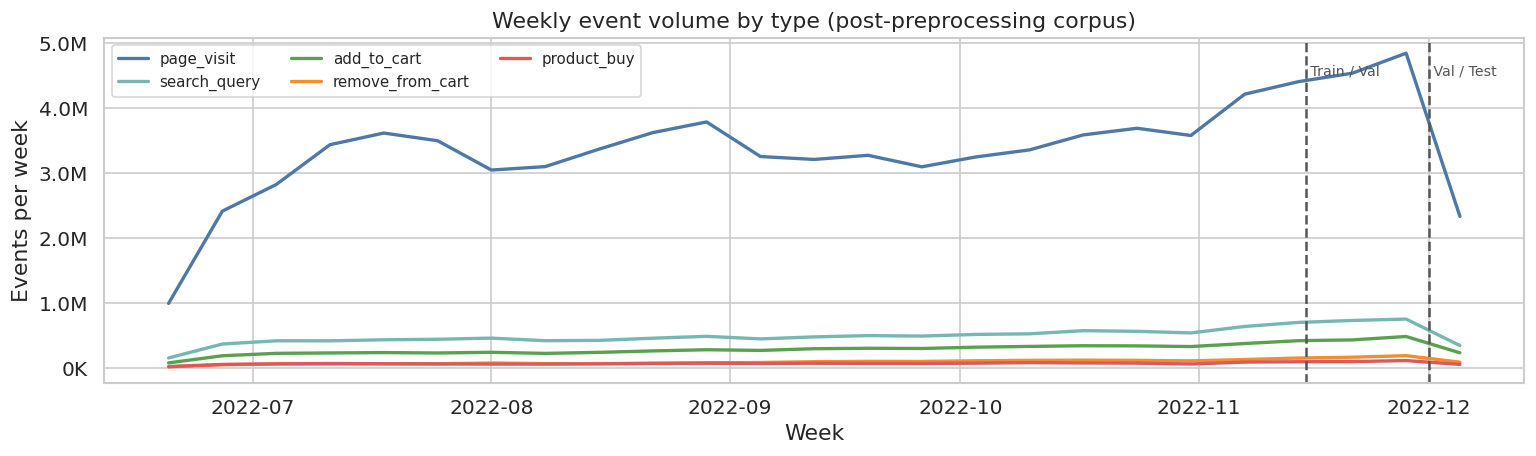

In [5]:
# Weekly event volume by type on the post-preprocessing corpus
weekly = (
    events_30
    .with_columns(pl.col('timestamp').dt.truncate('1w').alias('week'))
    .group_by(['week', 'event_type'])
    .len()
    .to_pandas()
    .pivot(index='week', columns='event_type', values='len')
    .reindex(columns=ACTION_TYPES, fill_value=0)
    .fillna(0)
    .sort_index()
)

colors_map = {
    'page_visit': '#4e79a7',
    'search_query': '#76b7b2',
    'add_to_cart': '#59a14f',
    'remove_from_cart': '#f28e2b',
    'product_buy': '#e15759',
}

fig, ax = plt.subplots(figsize=(13, 4))
for col in weekly.columns:
    ax.plot(weekly.index, weekly[col], lw=2, label=col, color=colors_map[col])

for dt, label, col in [
    (TRAIN_CUTOFF_TS, 'Train / Val', '#555'),
    (VAL_CUTOFF_TS,   'Val / Test',  '#555'),
]:
    ax.axvline(dt, color=col, ls='--', lw=1.5)
    ax.text(dt, ax.get_ylim()[1] * 0.92 if ax.get_ylim()[1] > 0 else 1,
            f' {label}', fontsize=8.5, color=col, va='top')

ax.set_xlabel('Week')
ax.set_ylabel('Events per week')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M' if v >= 1e6 else f'{v/1e3:.0f}K'))
ax.set_title('Weekly event volume by type (post-preprocessing corpus)')
ax.legend(ncol=3, fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

## 2 · Inter-event gap distribution


In [6]:
# Inter-event gaps on the post-preprocessing corpus (page-visit-only sessions already removed)
gaps_s = (
    events_all
    .select(['client_id', 'timestamp'])
    .sort(['client_id', 'timestamp'])
    .with_columns(pl.col('timestamp').diff().over('client_id').dt.total_seconds().alias('gap_s'))
    .drop_nulls('gap_s')
    .filter(pl.col('gap_s') >= 0)
    .get_column('gap_s')
    .to_numpy()
)

print(f'Within-user consecutive gaps: {len(gaps_s):,}')
print('(computed on the post-preprocessing corpus used by the pipeline)\n')

pct_labels = [5, 10, 25, 50, 75, 90, 95, 99]
pct_vals = np.quantile(gaps_s, np.array(pct_labels) / 100)
pct_df = pd.DataFrame({'percentile': pct_labels, 'seconds': pct_vals})
pct_df['minutes'] = pct_df.seconds / 60
pct_df['human'] = pct_df['minutes'].map(
    lambda m: f'{m/60/24:.1f} d' if m >= 24*60 else (f'{m/60:.1f} h' if m >= 60 else f'{m:.1f} min')
)
print(pct_df.to_string(index=False))

Within-user consecutive gaps: 105,125,332
(computed on the post-preprocessing corpus used by the pipeline)



 percentile     seconds    minutes   human
          5      0.0000     0.0000 0.0 min
         10      0.0000     0.0000 0.0 min
         25      0.0000     0.0000 0.0 min
         50     10.0000     0.1667 0.2 min
         75     35.0000     0.5833 0.6 min
         90    120.0000     2.0000 2.0 min
         95    390.0000     6.5000 6.5 min
         99 676330.0000 11272.1667   7.8 d


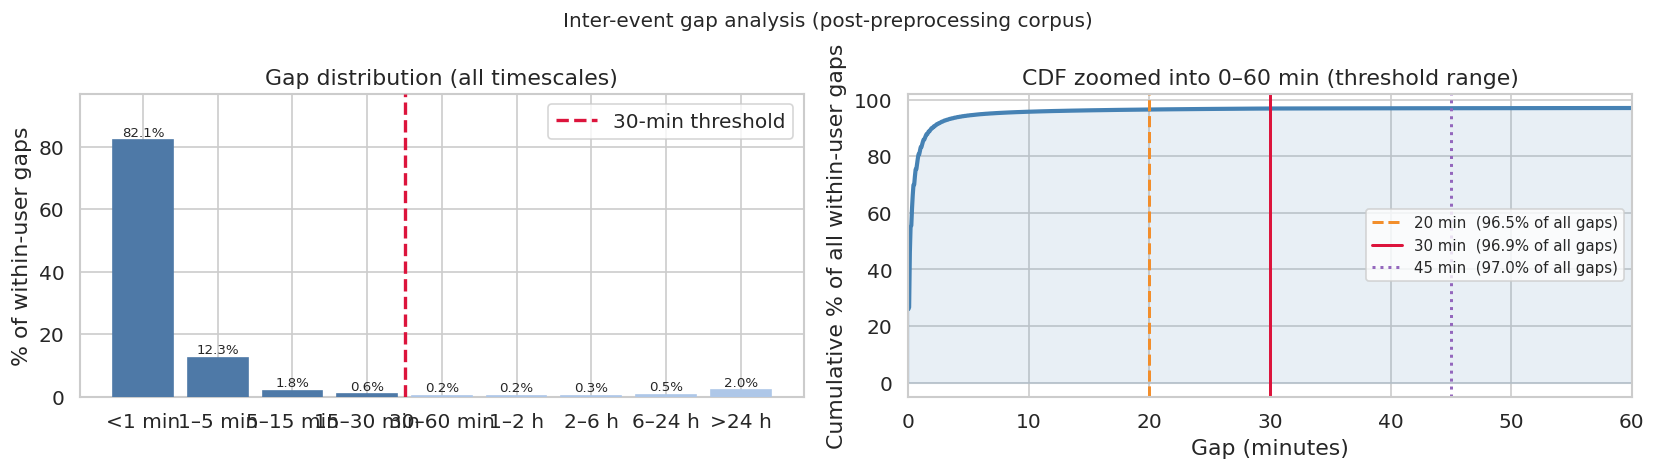

Sensitivity: fraction of ALL within-user gaps that exceed threshold
  >10 min: 4.27%
  >15 min: 3.79%


  >20 min: 3.50%
  >30 min: 3.15%
  >45 min: 3.04%


  >60 min: 2.97%


In [7]:
BUCKETS = [
    ('<1 min',    0,      60),
    ('1–5 min',   60,     300),
    ('5–15 min',  300,    900),
    ('15–30 min', 900,    1800),
    ('30–60 min', 1800,   3600),
    ('1–2 h',     3600,   7200),
    ('2–6 h',     7200,   21600),
    ('6–24 h',    21600,  86400),
    ('>24 h',     86400,  np.inf),
]
labels = [b[0] for b in BUCKETS]
counts = [int(((gaps_s >= lo) & (gaps_s < hi)).sum()) for _, lo, hi in BUCKETS]
pcts   = [c / len(gaps_s) * 100 for c in counts]

sub_hour = np.sort(gaps_s[gaps_s < 3600])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

palette = sns.color_palette('Blues_d', len(BUCKETS))
bars = axes[0].bar(labels, pcts, color=palette, edgecolor='white', zorder=3)
for i, (bar, pct) in enumerate(zip(bars, pcts)):
    bar.set_color('#4e79a7' if i < 4 else '#aec7e8')
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)
axes[0].axvline(x=3.5, color='crimson', lw=2, ls='--', label='30-min threshold', zorder=4)
axes[0].set_ylabel('% of within-user gaps')
axes[0].set_title('Gap distribution (all timescales)')
axes[0].legend()
axes[0].set_ylim(0, max(pcts) * 1.18)

x_cdf = np.linspace(0, 3600, 1000)
if len(sub_hour):
    cdf = np.searchsorted(sub_hour, x_cdf, side='right') / len(gaps_s) * 100
else:
    cdf = np.zeros_like(x_cdf)
axes[1].plot(x_cdf / 60, cdf, color='steelblue', lw=2.5)
axes[1].fill_between(x_cdf / 60, cdf, alpha=0.12, color='steelblue')

for mins, col, ls in [(20, '#f28e2b', '--'), (30, 'crimson', '-'), (45, '#9467bd', ':')]:
    frac = (gaps_s <= mins * 60).mean() * 100
    axes[1].axvline(mins, color=col, ls=ls, lw=1.8, label=f'{mins} min  ({frac:.1f}% of all gaps)')

axes[1].set_xlabel('Gap (minutes)')
axes[1].set_ylabel('Cumulative % of all within-user gaps')
axes[1].set_title('CDF zoomed into 0–60 min (threshold range)')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 60)

plt.suptitle('Inter-event gap analysis (post-preprocessing corpus)', fontsize=12)
plt.tight_layout()
plt.show()

print('Sensitivity: fraction of ALL within-user gaps that exceed threshold')
for mins in [10, 15, 20, 30, 45, 60]:
    print(f'  >{mins:2d} min: {(gaps_s > mins*60).mean()*100:.2f}%')

## 3 · Sessionisation sensitivity
Compare session counts and length distributions across three inactivity thresholds.

In [8]:
thresholds = [20, 30, 45]
base_events = events_all.select(['client_id', 'timestamp', 'event_type'])
sess_stats = {}
for t in thresholds:
    ev = sessionize_pl(base_events, t)
    sizes = ev.group_by('session_id').len().get_column('len').to_numpy()
    sess_stats[t] = {
        'n_sessions': len(sizes),
        'mean': float(sizes.mean()),
        'median': float(np.median(sizes)),
        'p75': float(np.quantile(sizes, 0.75)),
        'p90': float(np.quantile(sizes, 0.90)),
        'p95': float(np.quantile(sizes, 0.95)),
        'p99': float(np.quantile(sizes, 0.99)),
        'max': int(sizes.max()),
        'sizes': sizes,
    }

baseline = sess_stats[30]['n_sessions']
print(f'Baseline (30 min): {baseline:,} sessions\n')
for t in thresholds:
    s = sess_stats[t]
    delta = (s['n_sessions'] - baseline) / baseline * 100
    sign = f'({delta:+.2f}%)' if t != 30 else '(baseline)'
    print(f'  {t:2d} min → {s["n_sessions"]:>11,} sessions {sign}')
    print(f'         mean={s["mean"]:.2f}  median={s["median"]:.0f}  '
          f'p75={int(s["p75"])}  p90={int(s["p90"])}  p99={int(s["p99"])}  max={s["max"]}')

Baseline (30 min): 6,800,479 sessions

  20 min →   7,172,520 sessions (+5.47%)
         mean=15.14  median=9  p75=17  p90=34  p99=106  max=5274
  30 min →   6,800,479 sessions (baseline)
         mean=15.97  median=9  p75=18  p90=35  p99=112  max=5274
  45 min →   6,688,705 sessions (-1.64%)
         mean=16.24  median=9  p75=19  p90=36  p99=115  max=5274


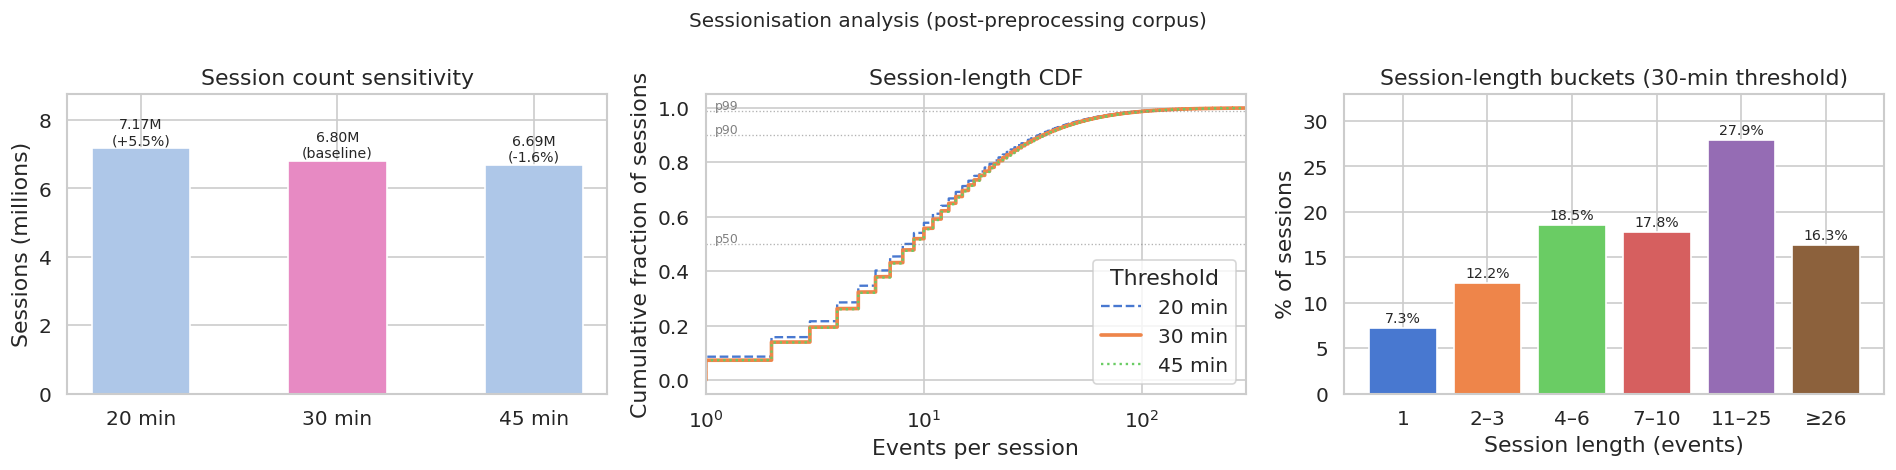

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ns = [sess_stats[t]['n_sessions'] / 1e6 for t in thresholds]
clrs = ['#aec7e8', '#e78ac3', '#aec7e8']
bars = axes[0].bar([f'{t} min' for t in thresholds], ns, color=clrs, edgecolor='white', width=0.5)
base = sess_stats[30]['n_sessions'] / 1e6
for bar, n, t in zip(bars, ns, thresholds):
    delta = 'baseline' if t == 30 else f'{(n-base)/base*100:+.1f}%'
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{n:.2f}M\n({delta})', ha='center', va='bottom', fontsize=8.5)
axes[0].set_ylabel('Sessions (millions)')
axes[0].set_title('Session count sensitivity')
axes[0].set_ylim(0, max(ns) * 1.22)

for t, ls, lw in zip(thresholds, ['--', '-', ':'], [1.4, 2.2, 1.4]):
    sizes = np.sort(sess_stats[t]['sizes'])
    cdf = np.arange(1, len(sizes)+1) / len(sizes)
    axes[1].plot(sizes, cdf, label=f'{t} min', lw=lw, ls=ls)
axes[1].set_xscale('log')
axes[1].set_xlim(1, 300)
axes[1].set_xlabel('Events per session')
axes[1].set_ylabel('Cumulative fraction of sessions')
axes[1].set_title('Session-length CDF')
axes[1].legend(title='Threshold')
for p, pv in [(0.5, 0.50), (0.9, 0.90), (0.99, 0.99)]:
    axes[1].axhline(pv, color='grey', ls=':', lw=0.8, alpha=0.6)
    axes[1].text(1.1, pv + 0.005, f'p{int(p*100)}', fontsize=7.5, color='grey')

sizes_30 = sess_stats[30]['sizes']
len_buckets = [(1, 1, '1'), (2, 3, '2–3'), (4, 6, '4–6'), (7, 10, '7–10'), (11, 25, '11–25'), (26, None, '≥26')]
bl, bv = [], []
for lo, hi, lbl in len_buckets:
    mask = (sizes_30 >= lo) & (sizes_30 <= hi) if hi else (sizes_30 >= lo)
    bl.append(lbl)
    bv.append(mask.sum() / len(sizes_30) * 100)

bars2 = axes[2].bar(bl, bv, color=sns.color_palette('muted', len(bl)), edgecolor='white')
for bar, v in zip(bars2, bv):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=8.5)
axes[2].set_xlabel('Session length (events)')
axes[2].set_ylabel('% of sessions')
axes[2].set_title('Session-length buckets (30-min threshold)')
axes[2].set_ylim(0, max(bv) * 1.18)

plt.suptitle('Sessionisation analysis (post-preprocessing corpus)', fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
print(f'Post-preprocessing corpus (30 min): {events_30.height:,} events  |  sessions: {events_30["session_id"].n_unique():,}')
print(f'Training split:                    {ev_train.height:,} events  |  sessions: {ev_train["session_id"].n_unique():,}')

Post-preprocessing corpus (30 min): 108,617,677 events  |  sessions: 6,800,479
Training split:                    88,170,139 events  |  sessions: 5,440,150


## 4 · Vocabulary coverage
Training split only (timestamp < 2022-11-15). The key chart for choosing K.

In [11]:
item_train_parts = []
for name in ['add_to_cart','remove_from_cart','product_buy']:
    df = item_dfs[name]
    train = df[df.timestamp < TRAIN_CUTOFF].copy()
    item_train_parts.append(train)
    print(f'{name:20}: {len(train):>9,} / {len(df):>9,} in train')

item_train = pd.concat(item_train_parts, ignore_index=True)
N_item     = len(item_train)
N_skus     = item_train.sku.nunique()
print(f'\nTotal item-bearing train events: {N_item:,}')
print(f'Unique SKUs:                     {N_skus:,}')

sku_freq   = item_train.sku.value_counts()
cumulative = sku_freq.cumsum()

add_to_cart         : 5,842,772 / 7,379,444 in train
remove_from_cart    : 1,933,288 / 2,535,219 in train


product_buy         : 1,562,630 / 1,937,579 in train

Total item-bearing train events: 9,338,690
Unique SKUs:                     1,305,867


In [12]:
K_probe = [100,500,1_000,2_000,5_000,10_000,20_000,50_000,
           100_000,200_000,500_000,750_000,1_000_000]

cov_pct = []
unk_pct = []
for K in K_probe:
    if K <= len(sku_freq):
        cov = cumulative.iloc[K-1] / N_item * 100
    else:
        cov = 100.0
    cov_pct.append(cov)
    unk_pct.append(100 - cov)

cov_df = pd.DataFrame({'K': K_probe, 'coverage': cov_pct, 'unk': unk_pct})
print(cov_df.to_string(index=False))

      K  coverage     unk
    100    3.1139 96.8861
    500    7.8574 92.1426
   1000   11.3285 88.6715
   2000   15.8661 84.1339
   5000   23.7157 76.2843
  10000   31.0132 68.9868
  20000   39.2570 60.7430
  50000   51.3108 48.6892
 100000   61.1894 38.8106
 200000   71.7105 28.2895
 500000   86.1705 13.8295
 750000   92.0495  7.9505
1000000   96.7247  3.2753


In [13]:
# K needed for target coverages
print('K needed for target coverage:')
for target in [50,80,90,95,99]:
    k = int((cumulative <= N_item * target / 100).sum()) + 1
    print(f'  {target}% → K = {k:,}')

K needed for target coverage:
  50% → K = 45,456
  80% → K = 338,307
  90% → K = 654,304
  95% → K = 887,771
  99% → K = 1,212,481


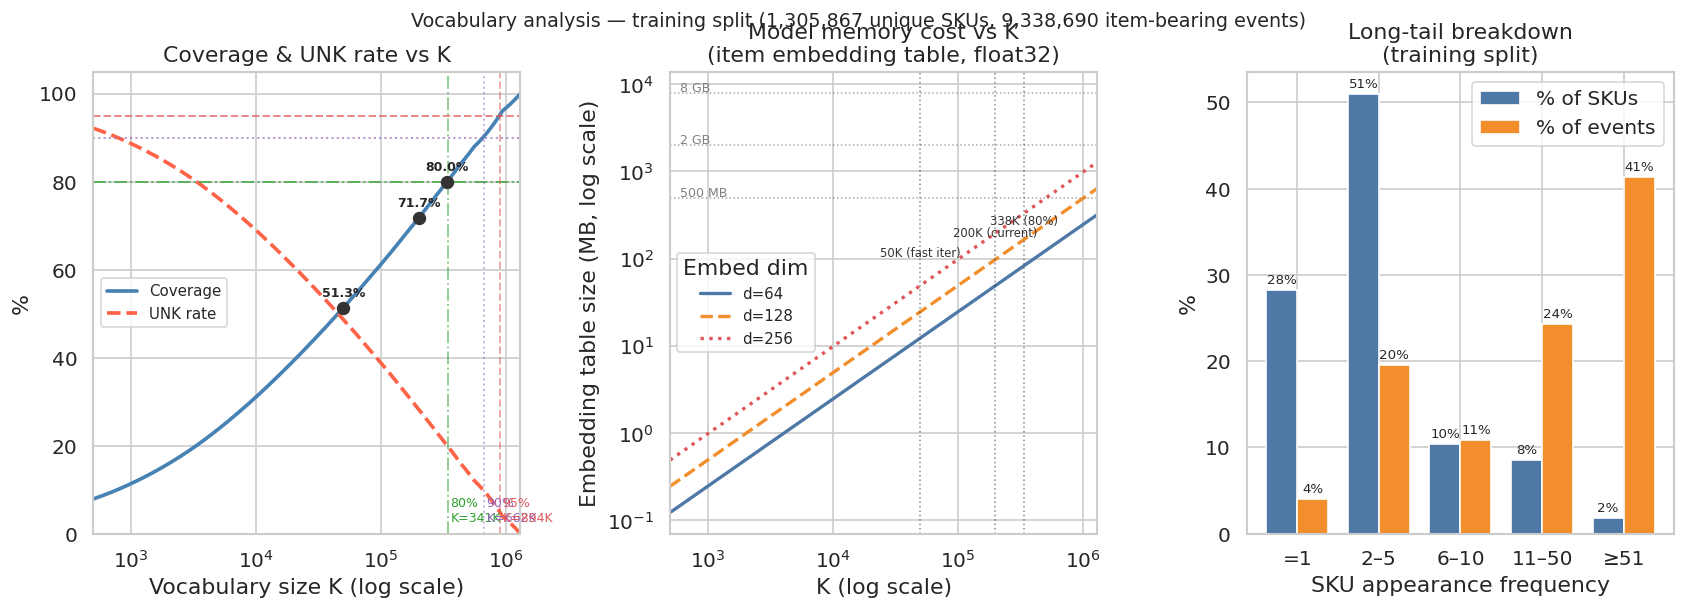

In [14]:
# Dense coverage curve for annotation
K_dense = np.unique(np.concatenate([
    np.geomspace(500, N_skus, 500).astype(int),
])).clip(1, len(sku_freq))
cov_dense = cumulative.iloc[K_dense - 1].values / N_item * 100

k80 = int((cumulative < N_item * 0.80).sum()) + 1
k90 = int((cumulative < N_item * 0.90).sum()) + 1
k95 = int((cumulative < N_item * 0.95).sum()) + 1
current_k = min(VOCAB_K - 1, len(sku_freq))

ABLATION_K = {
    '50K\n(fast iter)': 50_000,
    f'{VOCAB_K//1000}K\n(current)': current_k,
    f'{k80//1000}K\n(80%)': k80,
}
EMBED_DIMS = [64, 128, 256]

fig = plt.figure(figsize=(17, 5))
gs = fig.add_gridspec(1, 3, wspace=0.35)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])

ax0.plot(K_dense, cov_dense, color='steelblue', lw=2.2, label='Coverage')
ax0.plot(K_dense, 100 - cov_dense, color='tomato', lw=2.2, ls='--', label='UNK rate')

for target, col, ls in [(80, '#2ca02c', '-.'), (90, '#9467bd', ':'), (95, '#e15759', '--')]:
    ax0.axhline(target, color=col, ls=ls, lw=1.2, alpha=0.7)
    k_cross = K_dense[cov_dense >= target]
    if len(k_cross):
        ax0.axvline(k_cross[0], color=col, ls=ls, lw=1.2, alpha=0.5)
        ax0.text(k_cross[0] * 1.05, 2, f'{target}%\nK={k_cross[0]//1000}K',
                 fontsize=7.5, color=col, va='bottom')

for lbl, K in ABLATION_K.items():
    cov_k = cumulative.iloc[K-1] / N_item * 100
    ax0.plot(K, cov_k, 'o', ms=7, color='#333', zorder=5)
    ax0.text(K, cov_k + 2.5, f'{cov_k:.1f}%', ha='center', fontsize=7.5, fontweight='bold')

ax0.set_xscale('log')
ax0.set_xlim(500, N_skus)
ax0.set_ylim(0, 105)
ax0.set_xlabel('Vocabulary size K (log scale)')
ax0.set_ylabel('%')
ax0.set_title('Coverage & UNK rate vs K')
ax0.legend(fontsize=9)

for d, col, ls in zip(EMBED_DIMS, ['#4e79a7', '#f28e2b', '#e15759'], ['-', '--', ':']):
    mb = K_dense * d * 4 / 1024**2
    ax1.plot(K_dense, mb, color=col, lw=2, ls=ls, label=f'd={d}')
for mb_ref, label in [(500, '500 MB'), (2000, '2 GB'), (8000, '8 GB')]:
    ax1.axhline(mb_ref, color='grey', ls=':', lw=0.9, alpha=0.7)
    ax1.text(600, mb_ref * 1.04, label, fontsize=7.5, color='grey')
for lbl, K in ABLATION_K.items():
    mb128 = K * 128 * 4 / 1024**2
    ax1.axvline(K, color='#333', ls=':', lw=1, alpha=0.5)
    ax1.text(K, mb128 + 80, lbl.replace('\n', ' '), ha='center', fontsize=7, color='#333')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(500, N_skus)
ax1.set_xlabel('K (log scale)')
ax1.set_ylabel('Embedding table size (MB, log scale)')
ax1.set_title('Model memory cost vs K\n(item embedding table, float32)')
ax1.legend(title='Embed dim', fontsize=9)

freq_buckets = [(1, 1, '=1'), (2, 5, '2–5'), (6, 10, '6–10'), (11, 50, '11–50'), (51, None, '≥51')]
bl = [lb for _, _, lb in freq_buckets]
bs, be = [], []
for lo, hi, _ in freq_buckets:
    mask = (sku_freq >= lo) & (sku_freq <= hi) if hi else (sku_freq >= lo)
    bs.append(mask.sum())
    be.append(sku_freq[mask].sum())

x = np.arange(len(bl))
w = 0.38
b1 = ax2.bar(x - w/2, [v / N_skus * 100 for v in bs], w, label='% of SKUs', color='#4e79a7', edgecolor='white')
b2 = ax2.bar(x + w/2, [v / N_item * 100 for v in be], w, label='% of events', color='#f28e2b', edgecolor='white')
for bar, v in list(zip(b1, [v / N_skus * 100 for v in bs])) + list(zip(b2, [v / N_item * 100 for v in be])):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
             f'{v:.0f}%', ha='center', va='bottom', fontsize=8)
ax2.set_xticks(x)
ax2.set_xticklabels(bl)
ax2.set_xlabel('SKU appearance frequency')
ax2.set_ylabel('%')
ax2.set_title('Long-tail breakdown\n(training split)')
ax2.legend()

plt.suptitle(
    f'Vocabulary analysis — training split ({N_skus:,} unique SKUs, {N_item:,} item-bearing events)',
    fontsize=11.5,
)
plt.tight_layout()
plt.show()

In [15]:
# Tractability table for the current flat top-K item vocabulary choice
k80 = int((cumulative < N_item * 0.80).sum()) + 1
k90 = int((cumulative < N_item * 0.90).sum()) + 1
k95 = int((cumulative < N_item * 0.95).sum()) + 1
k99 = int((cumulative < N_item * 0.99).sum()) + 1
current_k = min(VOCAB_K - 1, len(sku_freq))

sweep_K = [50_000, 100_000, current_k, k80, k90, k95, k99]
rows = []
for K in sweep_K:
    cov = cumulative.iloc[K-1] / N_item * 100
    unk = 100 - cov
    rows.append({
        'K': K,
        'Coverage': f'{cov:.1f}%',
        'UNK rate': f'{unk:.1f}%',
        'Embed MB (d=64)': int(round(K * 64 * 4 / 1024**2)),
        'Embed MB (d=128)': int(round(K * 128 * 4 / 1024**2)),
        'Embed MB (d=256)': int(round(K * 256 * 4 / 1024**2)),
        'Note': (
            'fast iteration' if K == 50_000 else
            'current pipeline' if K == current_k else
            '80% coverage' if K == k80 else
            '90% coverage' if K == k90 else
            '95% coverage' if K == k95 else
            '99% coverage' if K == k99 else ''
        )
    })

tract_df = pd.DataFrame(rows).drop_duplicates(subset='K').sort_values('K')
print('Tractability of flat top-K item vocabulary choices')
print('(float32 item embedding table; PAD index consumes one reserved slot in VOCAB_K)\n')
print(tract_df.to_string(index=False))

Tractability of flat top-K item vocabulary choices
(float32 item embedding table; PAD index consumes one reserved slot in VOCAB_K)

      K Coverage UNK rate  Embed MB (d=64)  Embed MB (d=128)  Embed MB (d=256)             Note
  50000    51.3%    48.7%               12                24                49   fast iteration
 100000    61.2%    38.8%               24                49                98                 
 199999    71.7%    28.3%               49                98               195 current pipeline
 338306    80.0%    20.0%               83               165               330     80% coverage
 654304    90.0%    10.0%              160               319               639     90% coverage
 887771    95.0%     5.0%              217               433               867     95% coverage
1212481    99.0%     1.0%              296               592              1184     99% coverage


## 5 · Action bigram transition matrix
Training split, 30-min sessions. Identifies soft-constraint candidates.

In [16]:
ev_train_s = ev_train.select(['session_id', 'timestamp', 'event_type']).sort(['session_id', 'timestamp'])
transitions = (
    ev_train_s
    .with_columns(pl.col('event_type').shift(-1).over('session_id').alias('next_event'))
    .drop_nulls('next_event')
)

counts_raw = (
    transitions.group_by(['event_type', 'next_event'])
               .len()
               .to_pandas()
               .pivot(index='event_type', columns='next_event', values='len')
               .reindex(index=ACTION_TYPES, columns=ACTION_TYPES, fill_value=0)
               .fillna(0)
               .astype(int)
)
probs = counts_raw.div(counts_raw.sum(axis=1), axis=0)

print(f'Transitions: {int(counts_raw.values.sum()):,}\n')
print('Row-normalised probability matrix:')
print(probs.round(4).to_string())

Transitions: 82,729,989

Row-normalised probability matrix:
next_event        page_visit  search_query  add_to_cart  remove_from_cart  product_buy
event_type                                                                            
page_visit            0.7809        0.1210       0.0746            0.0140       0.0095
search_query          0.8573        0.1319       0.0085            0.0016       0.0007
add_to_cart           0.7584        0.0521       0.1172            0.0516       0.0206
remove_from_cart      0.4955        0.0348       0.0642            0.3768       0.0286
product_buy           0.5649        0.0143       0.0060            0.0045       0.4103


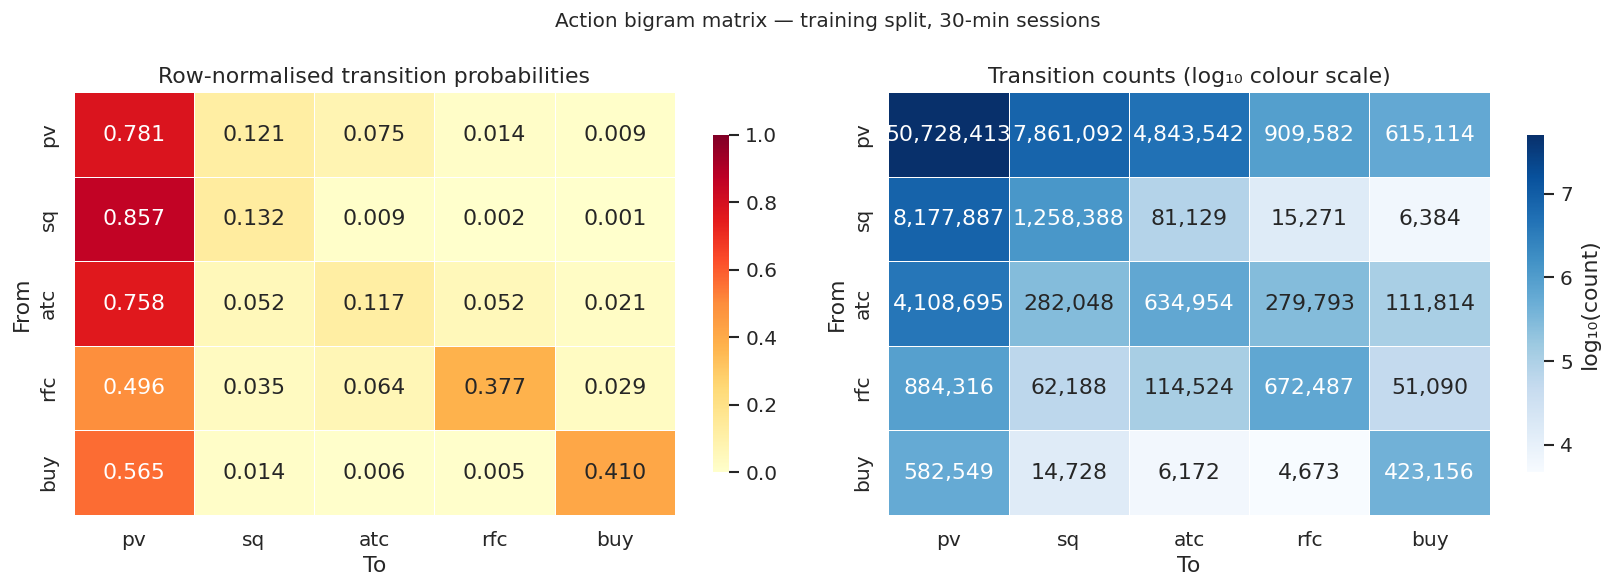

In [17]:
short = {'page_visit':'pv','search_query':'sq','add_to_cart':'atc',
         'remove_from_cart':'rfc','product_buy':'buy'}

mat   = probs.rename(index=short, columns=short)
c_mat = counts_raw.rename(index=short, columns=short)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: probability heatmap
sns.heatmap(mat, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=axes[0],
            vmin=0, vmax=1, cbar_kws={'shrink': 0.8})
axes[0].set_title('Row-normalised transition probabilities')
axes[0].set_xlabel('To')
axes[0].set_ylabel('From')

# Right: log-count heatmap
log_c = np.log10(c_mat.replace(0, np.nan).astype(float))
annot = c_mat.map(lambda v: f'{v:,}' if v > 0 else '0')
sns.heatmap(log_c, annot=annot, fmt='', cmap='Blues',
            linewidths=0.5, linecolor='white', ax=axes[1],
            cbar_kws={'shrink': 0.8, 'label': 'log₁₀(count)'})
axes[1].set_title('Transition counts (log₁₀ colour scale)')
axes[1].set_xlabel('To')
axes[1].set_ylabel('From')

plt.suptitle('Action bigram matrix — training split, 30-min sessions', fontsize=12)
plt.tight_layout()
plt.show()

Rarest transitions (count > 0):
        from               to   prob  count
search_query      product_buy 0.0007   6384
search_query remove_from_cart 0.0016  15271
 product_buy remove_from_cart 0.0045   4673
 product_buy      add_to_cart 0.0060   6172
search_query      add_to_cart 0.0085  81129

Soft-constraint candidates (<1% row-prob):
        from               to   prob  count
search_query      product_buy 0.0007   6384
search_query remove_from_cart 0.0016  15271
 product_buy remove_from_cart 0.0045   4673
 product_buy      add_to_cart 0.0060   6172
search_query      add_to_cart 0.0085  81129
  page_visit      product_buy 0.0095 615114

Never-observed:
  all 25 observed


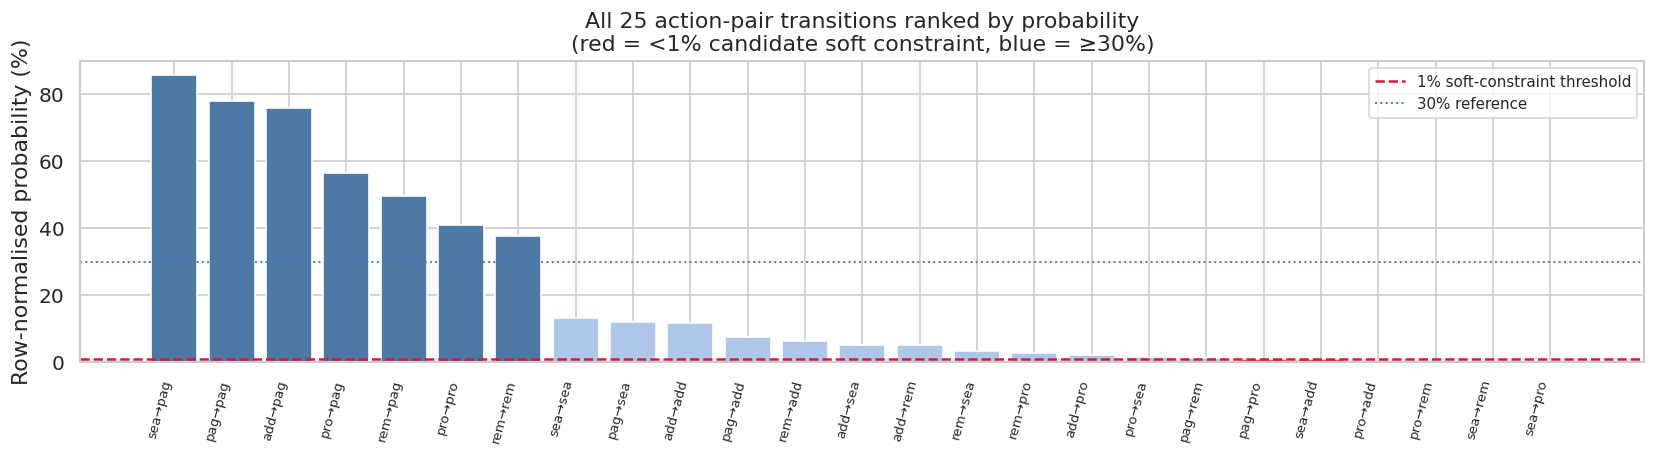

In [18]:
flat = probs.stack().reset_index()
flat.columns = ['from','to','prob']
flat['count'] = counts_raw.stack().values
flat['pair']  = flat['from'].str[:3] + '→' + flat['to'].str[:3]

observed = flat[flat['count'] > 0].sort_values('prob')
rare     = observed[observed['prob'] < 0.01]
never    = flat[flat['count'] == 0]

print('Rarest transitions (count > 0):')
print(observed.head(5)[['from','to','prob','count']].to_string(index=False))
print('\nSoft-constraint candidates (<1% row-prob):')
print(rare[['from','to','prob','count']].to_string(index=False) if len(rare) else '  none')
print('\nNever-observed:')
print('  all 25 observed' if len(never) == 0 else never[['from','to']].to_string(index=False))

# Bar chart: all 25 transitions ranked by probabilit
ranked = flat.sort_values('prob', ascending=False).reset_index(drop=True)
colors_bar = ['#e15759' if p < 0.01 else '#4e79a7' if p >= 0.30 else '#aec7e8'
              for p in ranked['prob']]

fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(range(len(ranked)), ranked['prob'] * 100, color=colors_bar, edgecolor='white')
ax.set_xticks(range(len(ranked)))
ax.set_xticklabels(ranked['pair'], rotation=75, ha='right', fontsize=8)
ax.axhline(1,  color='crimson', ls='--', lw=1.5, label='1% soft-constraint threshold')
ax.axhline(30, color='steelblue', ls=':', lw=1.2, label='30% reference')
ax.set_ylabel('Row-normalised probability (%)')
ax.set_title('All 25 action-pair transitions ranked by probability\n'
             '(red = <1% candidate soft constraint, blue = ≥30%)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6 · Exposure prerequisite analysis
For each `product_buy` event: was there a same-SKU `add_to_cart` in the same session, within 24 h, or ever?

In [19]:
# Exposure-prerequisite analysis on the post-preprocessing training split
train_item_events = (
    ev_train
    .filter(pl.col('event_type').is_in(['add_to_cart', 'product_buy']))
    .drop_nulls('sku')
    .select(['client_id', 'timestamp', 'session_id', 'sku', 'event_type'])
    .with_columns(pl.col('sku').cast(pl.Int64, strict=False))
    .to_pandas()
)

aw = train_item_events[train_item_events.event_type == 'add_to_cart'].rename(columns={'timestamp': 'atc_ts'})
bw = train_item_events[train_item_events.event_type == 'product_buy'].rename(columns={'timestamp': 'buy_ts'})
bw = bw.reset_index(drop=True).assign(buy_id=np.arange(len(bw)))

print(f'Training buy events:         {len(bw):,}')
print(f'Training add_to_cart events: {len(aw):,}')
print(f'\nTotal (after session join): {len(bw):,}')

Training buy events:         1,562,654
Training add_to_cart events: 5,843,051

Total (after session join): 1,562,654


In [20]:
# Same-session, same-SKU
ss = bw[['buy_id', 'session_id', 'buy_ts', 'sku']].merge(
    aw[['session_id', 'atc_ts', 'sku']], on=['session_id', 'sku']
)
n_same_sess = ss[ss.atc_ts < ss.buy_ts]['buy_id'].nunique()

# Cross-session: same client+SKU within 24 h / ever
bc = bw[['buy_id', 'client_id', 'buy_ts', 'sku']].copy()
ac = aw[['client_id', 'atc_ts', 'sku']].copy()
prior = bc.merge(ac, on=['client_id', 'sku'])
prior = prior[prior.atc_ts < prior.buy_ts]

n_24h = prior[(prior.buy_ts - prior.atc_ts) <= pd.Timedelta(hours=24)]['buy_id'].nunique()
n_any = prior['buy_id'].nunique()
total = len(bw)

results = {
    'Same-session\n(same SKU)': n_same_sess / total * 100,
    'Within 24h\n(same client+SKU)': n_24h / total * 100,
    'Any prior\n(same client+SKU)': n_any / total * 100,
    'No prior\nadd_to_cart': (1 - n_any / total) * 100,
}

print(f'  Same-session (same SKU)            : {n_same_sess/total*100:.2f}%')
print(f'  Within 24 h (same client+SKU)      : {n_24h/total*100:.2f}%')
print(f'  Any prior (same client+SKU)        : {n_any/total*100:.2f}%')
print(f'  No prior add_to_cart               : {(1 - n_any/total)*100:.2f}%')

  Same-session (same SKU)            : 53.32%
  Within 24 h (same client+SKU)      : 59.11%
  Any prior (same client+SKU)        : 63.55%
  No prior add_to_cart               : 36.45%


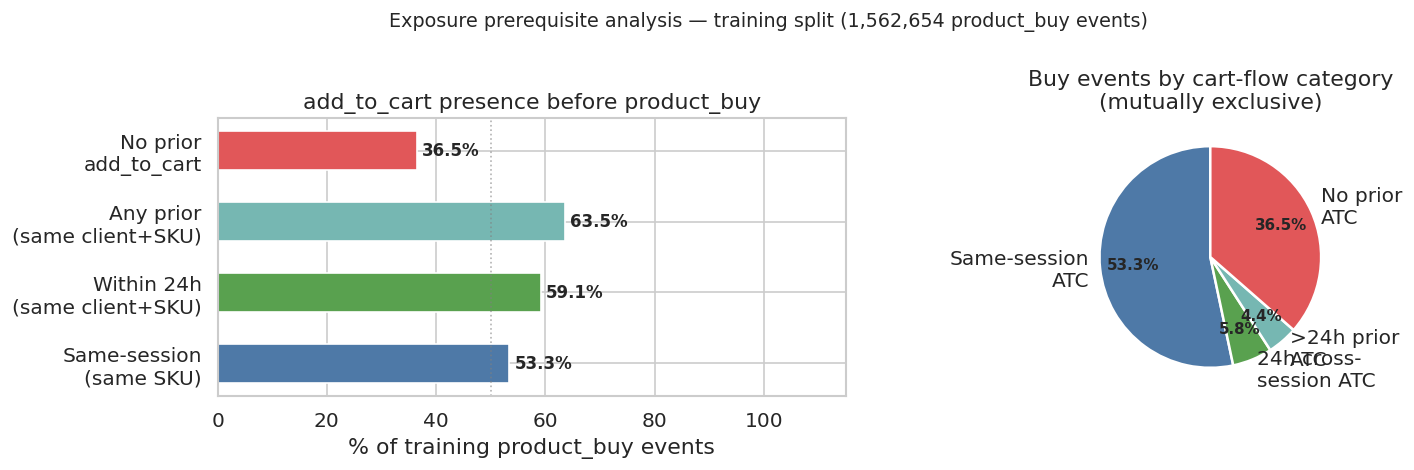

36.5% of buys have no prior same-SKU add_to_cart ever.
Hard prerequisite would block 36.5% of valid purchases.
Use a soft reward signal; a 24h look-back is more defensible than a same-session hard rule.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

labels_exp = ['Same-session\n(same SKU)', 'Within 24h\n(same client+SKU)',
              'Any prior\n(same client+SKU)', 'No prior\nadd_to_cart']
vals = list(results.values())
clrs = ['#4e79a7', '#59a14f', '#76b7b2', '#e15759']
bars = axes[0].barh(labels_exp, vals, color=clrs, edgecolor='white', height=0.55)
for bar, v in zip(bars, vals):
    axes[0].text(min(v + 1, 105), bar.get_y() + bar.get_height()/2,
                 f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')
axes[0].set_xlabel('% of training product_buy events')
axes[0].set_xlim(0, 115)
axes[0].set_title('add_to_cart presence before product_buy')
axes[0].axvline(50, color='grey', ls=':', lw=1, alpha=0.6)

n_A = n_same_sess
n_B = max(0, n_24h - n_same_sess)
n_C = max(0, n_any - n_24h)
n_D = total - n_any

categories = ['Same-session\nATC', '24h cross-\nsession ATC', '>24h prior\nATC', 'No prior\nATC']
values_mut = [n_A/total*100, n_B/total*100, n_C/total*100, n_D/total*100]
clrs2 = ['#4e79a7', '#59a14f', '#76b7b2', '#e15759']

wedges, texts, autotexts = axes[1].pie(
    values_mut, labels=categories, colors=clrs2,
    autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
    startangle=90, pctdistance=0.7,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for t in autotexts:
    t.set_fontsize(9)
    t.set_fontweight('bold')
axes[1].set_title('Buy events by cart-flow category\n(mutually exclusive)')

plt.suptitle(f'Exposure prerequisite analysis — training split ({total:,} product_buy events)', fontsize=11.5)
plt.tight_layout()
plt.show()

print(f'{n_D/total*100:.1f}% of buys have no prior same-SKU add_to_cart ever.')
print(f'Hard prerequisite would block {n_D/total*100:.1f}% of valid purchases.')
print('Use a soft reward signal; a 24h look-back is more defensible than a same-session hard rule.')

## 8 · Within-session δt distribution & temporal head bin design
Log-scale bin boundaries for the transformer's temporal encoding head.

Within-session gaps (0 < δt < 1800 s): 60,062,132



Percentiles (seconds):
  p 5:      5.0 s  (0.08 min)
  p10:      5.0 s  (0.08 min)
  p25:      5.0 s  (0.08 min)
  p50:     15.0 s  (0.25 min)
  p75:     45.0 s  (0.75 min)
  p90:    115.0 s  (1.92 min)
  p95:    210.0 s  (3.50 min)
  p99:    835.0 s  (13.92 min)

Instant events (δt < 1 s): 27.40% of within-session gaps

Bin mass analysis (geomspace 1s – 1800s):


  N= 32: CV=1.614  empty_bins=5  max_bin=25.89%  (ideal=3.12%)
  N= 64: CV=2.388  empty_bins=17  max_bin=25.89%  (ideal=1.56%)


  N=128: CV=3.474  empty_bins=44  max_bin=25.89%  (ideal=0.78%)



Chosen: 64 log-scale bins, edges[0]=1.00s, edges[-1]=1800s
Edge array (first 10): [1.   1.12 1.26 1.42 1.6  1.8  2.02 2.27 2.55 2.87]
All 65 bin edges (s): [1.0, 1.12, 1.26, 1.42, 1.6, 1.8, 2.02, 2.27, 2.55, 2.87, 3.23, 3.63, 4.08, 4.58, 5.15, 5.79, 6.51, 7.32, 8.23, 9.26, 10.41, 11.7, 13.15, 14.79, 16.62, 18.69, 21.01, 23.62, 26.56, 29.86, 33.57, 37.74, 42.43, 47.7, 53.62, 60.29, 67.78, 76.2, 85.67, 96.31, 108.28, 121.73, 136.86, 153.86, 172.98, 194.47, 218.64, 245.81, 276.35, 310.68, 349.29, 392.69, 441.48, 496.33, 558.0, 627.34, 705.28, 792.92, 891.44, 1002.2, 1126.73, 1266.72, 1424.12, 1601.06, 1800.0]


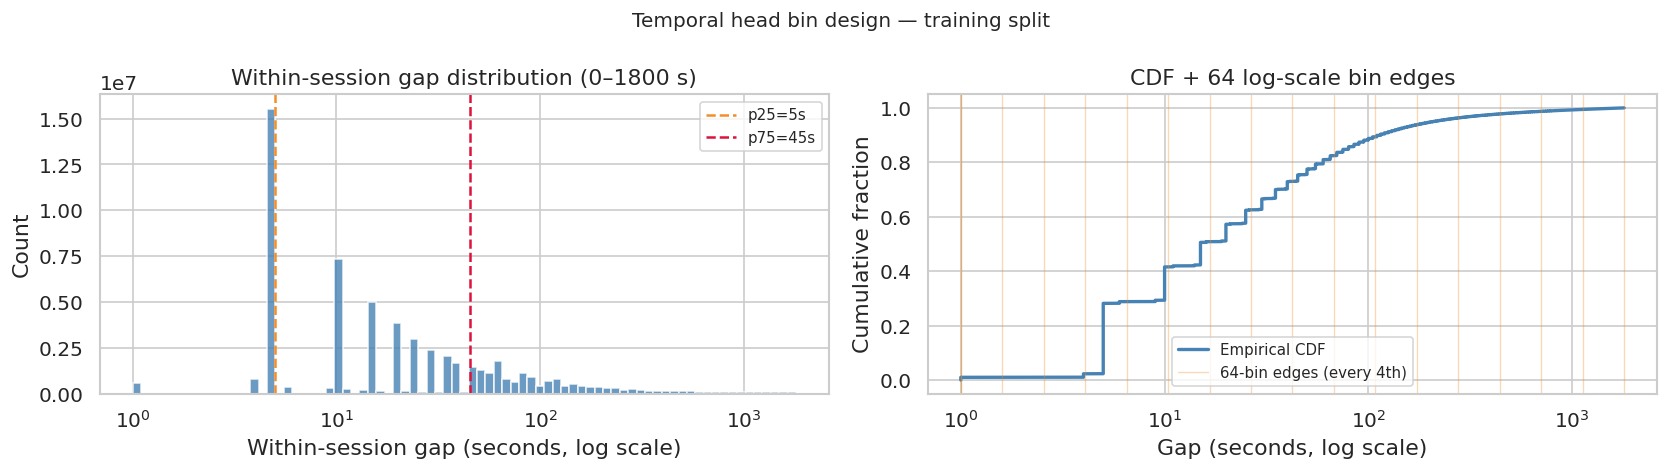


Recommendation: 64 log-scale bins, geomspace(1, 1800, 65)
N=64 stats: CV=2.388, 17 empty bins, max bin mass=25.89%
Mass in dense region (≤p90≈115s): 90.4%; sparse tail: 9.6%


In [22]:
# Within-session delta-t distribution on the post-preprocessing training split
all_session_gaps = (
    ev_train.select(['session_id', 'timestamp'])
            .sort(['session_id', 'timestamp'])
            .with_columns(pl.col('timestamp').diff().over('session_id').dt.total_seconds().alias('delta_s'))
            .drop_nulls('delta_s')
            .get_column('delta_s')
            .to_numpy()
)
within_gaps = all_session_gaps[(all_session_gaps > 0) & (all_session_gaps < SESSION_TIMEOUT_MIN * 60)]
print(f'Within-session gaps (0 < δt < {SESSION_TIMEOUT_MIN*60} s): {len(within_gaps):,}')

pcts = [5, 10, 25, 50, 75, 90, 95, 99]
vals = np.quantile(within_gaps, np.array(pcts) / 100)
print('\nPercentiles (seconds):')
for p, v in zip(pcts, vals):
    print(f'  p{p:2d}: {v:8.1f} s  ({v/60:.2f} min)')

instant_frac = (all_session_gaps < 1).sum() / len(all_session_gaps) * 100
print(f'\nInstant events (δt < 1 s): {instant_frac:.2f}% of within-session gaps')

N_BINS_OPTIONS = [32, 64, 128]
cv_by_n = {}
print(f'\nBin mass analysis (geomspace 1s – {SESSION_TIMEOUT_MIN*60}s):')
for nb_val in N_BINS_OPTIONS:
    edges = np.geomspace(1, SESSION_TIMEOUT_MIN * 60, nb_val + 1)
    counts_per_bin = np.histogram(within_gaps, bins=edges)[0]
    ideal_mass = 1 / nb_val
    am = counts_per_bin / counts_per_bin.sum()
    cv = am.std() / am.mean()
    n_empty = (counts_per_bin == 0).sum()
    max_mass = am.max() * 100
    cv_by_n[nb_val] = (cv, n_empty, max_mass)
    print(f'  N={nb_val:3d}: CV={cv:.3f}  empty_bins={n_empty}  max_bin={max_mass:.2f}%  '
          f'(ideal={ideal_mass*100:.2f}%)')

CHOSEN_BINS = 64
edges_64 = np.geomspace(1, SESSION_TIMEOUT_MIN * 60, CHOSEN_BINS + 1)
cv_64, empty_64, maxbin_64 = cv_by_n[CHOSEN_BINS]
dense_threshold = np.quantile(within_gaps, 0.90)
dense_mass = (within_gaps <= dense_threshold).sum() / len(within_gaps) * 100
sparse_mass = 100 - dense_mass
print(f'\nChosen: {CHOSEN_BINS} log-scale bins, edges[0]={edges_64[0]:.2f}s, edges[-1]={edges_64[-1]:.0f}s')
print(f'Edge array (first 10): {np.round(edges_64[:10], 2)}')
print(f'All {CHOSEN_BINS + 1} bin edges (s): {np.round(edges_64, 2).tolist()}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

log_bins = np.geomspace(1, SESSION_TIMEOUT_MIN * 60, 80)
axes[0].hist(within_gaps, bins=log_bins, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xscale('log')
axes[0].set_xlabel('Within-session gap (seconds, log scale)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Within-session gap distribution (0–{SESSION_TIMEOUT_MIN*60} s)')
for p_val, lbl, col in [(vals[2], 'p25', '#f28e2b'), (vals[4], 'p75', 'crimson')]:
    axes[0].axvline(p_val, color=col, ls='--', lw=1.5, label=f'{lbl}={p_val:.0f}s')
axes[0].legend(fontsize=9)

x_sorted = np.sort(within_gaps)
y_cdf = np.arange(1, len(x_sorted)+1) / len(x_sorted)
axes[1].plot(x_sorted, y_cdf, color='steelblue', lw=2, label='Empirical CDF')
for edge in edges_64[::4]:
    axes[1].axvline(edge, color='#f28e2b', alpha=0.35, lw=0.8)
axes[1].axvline(edges_64[0], color='#f28e2b', alpha=0.35, lw=0.8, label='64-bin edges (every 4th)')
axes[1].set_xscale('log')
axes[1].set_xlabel('Gap (seconds, log scale)')
axes[1].set_ylabel('Cumulative fraction')
axes[1].set_title('CDF + 64 log-scale bin edges')
axes[1].legend(fontsize=9)

plt.suptitle('Temporal head bin design — training split', fontsize=12)
plt.tight_layout()
plt.show()

print(f'\nRecommendation: 64 log-scale bins, geomspace(1, {SESSION_TIMEOUT_MIN*60}, 65)')
print(f'N=64 stats: CV={cv_64:.3f}, {empty_64} empty bins, max bin mass={maxbin_64:.2f}%')
print(f'Mass in dense region (≤p90≈{dense_threshold:.0f}s): {dense_mass:.1f}%; sparse tail: {sparse_mass:.1f}%')

## 9 · User-level statistics & context window H
Determines feasible values for the sequence length H fed to the transformer at inference.

Events per user:
  p50: 12
  p75: 27
  p90: 62
  p95: 105
  p99: 298
  mean: 30.0  max: 26704

Sessions per user:
  p50: 1
  p75: 2
  p90: 3
  p95: 5
  p99: 14
  mean: 1.9  max: 469

Sessions-per-user distribution:
         1: 72.6%
       2-5: 23.1%
      6-10: 2.7%
     11-50: 1.5%
       >50: 0.1%

Events-per-user distribution:
      <=10: 45.8%
     11-50: 41.4%
    51-200: 10.9%
      >200: 1.9%

Context window H coverage (% of users whose full history fits):
  H= 16: 60.9% of users
  H= 32: 79.2% of users
  H= 64: 90.5% of users
  H=128: 96.2% of users
  H=256: 98.7% of users


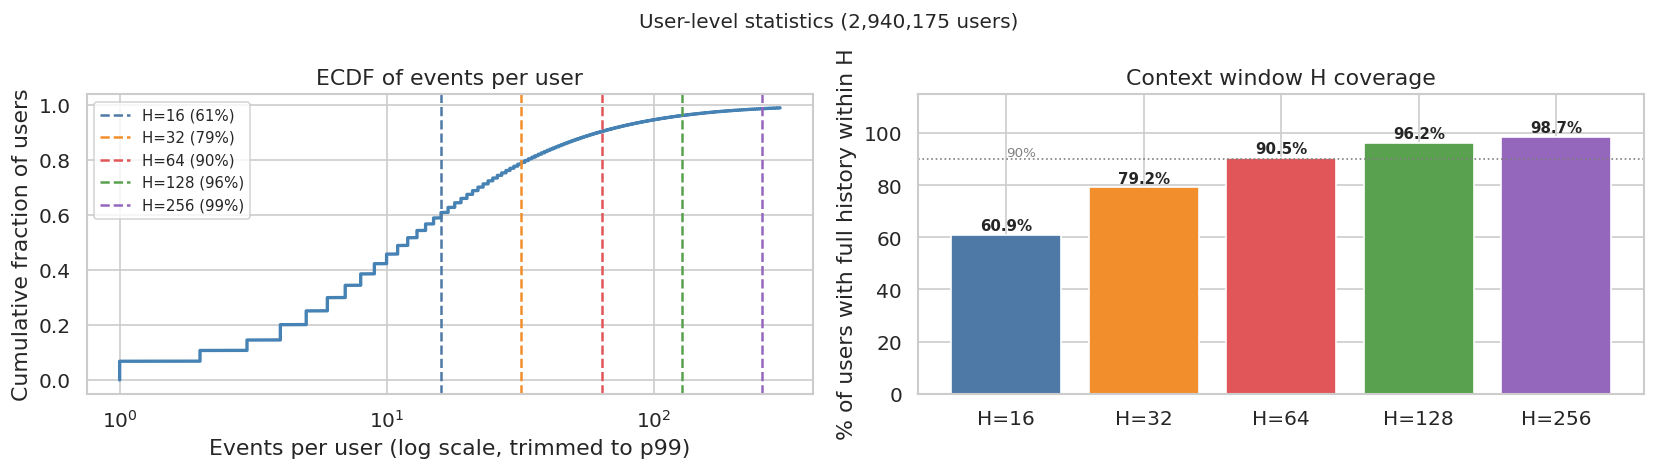


Current config: history_window=16 covers 60.9% of users' full event history


In [23]:
# User-level statistics on the post-preprocessing training split
user_stats = (
    ev_train.group_by('client_id')
            .agg([
                pl.len().alias('n_events'),
                pl.col('session_id').n_unique().alias('n_sessions'),
            ])
)
user_events = user_stats.get_column('n_events').to_numpy()
user_sessions = user_stats.get_column('n_sessions').to_numpy()

print('Events per user:')
for p in [50, 75, 90, 95, 99]:
    print(f'  p{p:2d}: {np.quantile(user_events, p/100):.0f}')
print(f'  mean: {user_events.mean():.1f}  max: {user_events.max()}')

print('\nSessions per user:')
for p in [50, 75, 90, 95, 99]:
    print(f'  p{p:2d}: {np.quantile(user_sessions, p/100):.0f}')
print(f'  mean: {user_sessions.mean():.1f}  max: {user_sessions.max()}')

print('\nSessions-per-user distribution:')
for lo, hi, lbl in [(1, 1, '1'), (2, 5, '2-5'), (6, 10, '6-10'), (11, 50, '11-50'), (51, None, '>50')]:
    mask = (user_sessions >= lo) & (user_sessions <= hi) if hi else (user_sessions >= lo)
    frac = mask.sum() / len(user_sessions) * 100
    print(f'  {lbl:>8}: {frac:.1f}%')

print('\nEvents-per-user distribution:')
for lo, hi, lbl in [(1, 10, '<=10'), (11, 50, '11-50'), (51, 200, '51-200'), (201, None, '>200')]:
    mask = (user_events >= lo) & (user_events <= hi) if hi else (user_events >= lo)
    frac = mask.sum() / len(user_events) * 100
    print(f'  {lbl:>8}: {frac:.1f}%')

print('\nContext window H coverage (% of users whose full history fits):')
H_vals = [16, 32, 64, 128, 256]
h_cov = []
for H in H_vals:
    frac = (user_events <= H).mean() * 100
    h_cov.append(frac)
    print(f'  H={H:3d}: {frac:.1f}% of users')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

p99_ev = np.quantile(user_events, 0.99)
ue_trim = np.sort(user_events[user_events <= p99_ev])
cdf_ue = np.arange(1, len(ue_trim)+1) / len(user_events)
axes[0].plot(ue_trim, cdf_ue, color='steelblue', lw=2)
axes[0].set_xscale('log')
for H, col in zip([16, 32, 64, 128, 256], ['#4e79a7', '#f28e2b', '#e15759', '#59a14f', '#9467bd']):
    frac = (user_events <= H).mean()
    axes[0].axvline(H, color=col, ls='--', lw=1.5, label=f'H={H} ({frac*100:.0f}%)')
axes[0].set_xlabel('Events per user (log scale, trimmed to p99)')
axes[0].set_ylabel('Cumulative fraction of users')
axes[0].set_title('ECDF of events per user')
axes[0].legend(fontsize=9)

bars = axes[1].bar([f'H={h}' for h in H_vals], h_cov,
                   color=['#4e79a7', '#f28e2b', '#e15759', '#59a14f', '#9467bd'], edgecolor='white')
for bar, v in zip(bars, h_cov):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_ylabel('% of users with full history within H')
axes[1].set_ylim(0, 115)
axes[1].set_title('Context window H coverage')
axes[1].axhline(90, color='grey', ls=':', lw=1)
axes[1].text(0, 91, '90%', fontsize=8, color='grey')

plt.suptitle(f'User-level statistics ({len(user_events):,} users)', fontsize=12)
plt.tight_layout()
plt.show()

current_cov = h_cov[H_vals.index(HISTORY_WINDOW)] if HISTORY_WINDOW in H_vals else None
if current_cov is not None:
    print(f'\nCurrent config: history_window={HISTORY_WINDOW} covers {current_cov:.1f}% of users\' full event history')

## 10 · Data split integrity & user overlap
Train, validation, and test summaries are computed from the preprocessed session-start split, not from raw event timestamps.

Event counts per split per action type:



  train (88,170,139 events, 2,940,175 users, 5,440,150 sessions):
    page_visit          : 68,846,102  (78.1%)
    search_query        : 9,984,908  (11.3%)
    add_to_cart         : 5,843,051  (6.6%)
    remove_from_cart    : 1,933,424  (2.2%)
    product_buy         : 1,562,654  (1.8%)

  val (13,689,549 events, 573,521 users, 910,386 sessions):
    page_visit          : 10,376,014  (75.8%)
    search_query        : 1,665,085  (12.2%)
    add_to_cart         : 1,012,668  (7.4%)
    remove_from_cart    :   391,695  (2.9%)
    product_buy         :   244,087  (1.8%)

  test (6,757,989 events, 317,002 users, 449,943 sessions):
    page_visit          : 5,106,959  (75.6%)
    search_query        :   786,367  (11.6%)
    add_to_cart         :   523,725  (7.7%)
    remove_from_cart    :   210,100  (3.1%)
    product_buy         :   130,838  (1.9%)



User overlap:
  train ∩ val  :  201,381  (35.1% of val users have training history)
  train ∩ test :  109,301  (34.5% of test users have training history)
  Cold-start (val)  : 64.9%
  Cold-start (test) : 65.5%


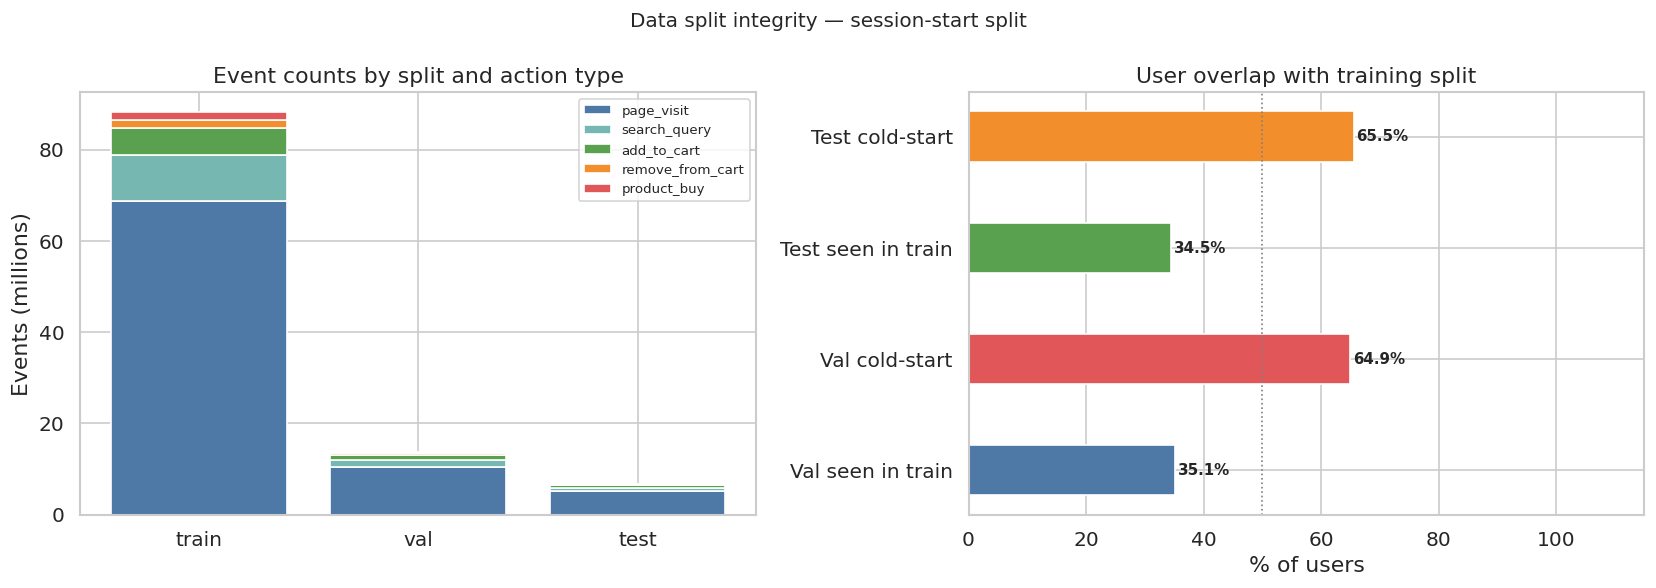

In [24]:
splits = {'train': ev_train, 'val': ev_val, 'test': ev_test}

print('Event counts per split per action type:')
for split_name, df in splits.items():
    total_sp = df.height
    by_type = {et: 0 for et in ACTION_TYPES}
    for et, n in df.group_by('event_type').len().iter_rows():
        by_type[et] = n
    print(f'\n  {split_name} ({total_sp:,} events, {df["client_id"].n_unique():,} users, {df["session_id"].n_unique():,} sessions):')
    for et in ACTION_TYPES:
        c = by_type.get(et, 0)
        print(f'    {et:20}: {c:>9,}  ({c/total_sp*100:.1f}%)')

train_users = set(ev_train.select('client_id').unique().get_column('client_id').to_list())
val_users   = set(ev_val.select('client_id').unique().get_column('client_id').to_list())
test_users  = set(ev_test.select('client_id').unique().get_column('client_id').to_list())

val_seen  = len(train_users & val_users) / len(val_users) * 100
test_seen = len(train_users & test_users) / len(test_users) * 100
val_cold  = 100 - val_seen
test_cold = 100 - test_seen

print('\nUser overlap:')
print(f'  train ∩ val  : {len(train_users & val_users):>8,}  ({val_seen:.1f}% of val users have training history)')
print(f'  train ∩ test : {len(train_users & test_users):>8,}  ({test_seen:.1f}% of test users have training history)')
print(f'  Cold-start (val)  : {val_cold:.1f}%')
print(f'  Cold-start (test) : {test_cold:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

split_counts = {}
for split_name, df in splits.items():
    tmp = {et: 0 for et in ACTION_TYPES}
    for et, n in df.group_by('event_type').len().iter_rows():
        tmp[et] = n
    split_counts[split_name] = tmp

bar_colors = ['#4e79a7', '#76b7b2', '#59a14f', '#f28e2b', '#e15759']
x = np.arange(len(splits))
bottoms = np.zeros(len(splits))
split_names = list(splits.keys())
for et, col in zip(ACTION_TYPES, bar_colors):
    vals_bar = [split_counts[s][et] / 1e6 for s in split_names]
    axes[0].bar(x, vals_bar, bottom=bottoms, label=et, color=col, edgecolor='white')
    bottoms += np.array(vals_bar)
axes[0].set_xticks(x)
axes[0].set_xticklabels(split_names)
axes[0].set_ylabel('Events (millions)')
axes[0].set_title('Event counts by split and action type')
axes[0].legend(fontsize=8, loc='upper right')

labels = ['Val seen in train', 'Val cold-start', 'Test seen in train', 'Test cold-start']
vals = [val_seen, val_cold, test_seen, test_cold]
cols = ['#4e79a7', '#e15759', '#59a14f', '#f28e2b']
bars = axes[1].barh(labels, vals, color=cols, edgecolor='white', height=0.45)
for bar, v in zip(bars, vals):
    axes[1].text(min(v + 0.5, 108), bar.get_y() + bar.get_height()/2,
                 f'{v:.1f}%', va='center', fontsize=9, fontweight='bold')
axes[1].set_xlabel('% of users')
axes[1].set_xlim(0, 115)
axes[1].axvline(50, color='grey', ls=':', lw=1)
axes[1].set_title('User overlap with training split')

plt.suptitle('Data split integrity — session-start split', fontsize=12)
plt.tight_layout()
plt.show()

## 11 · Vocabulary drift: exact train-vocabulary OOV in val/test
This section computes exact item-level OOV against the current train top-`K` vocabulary (`VOCAB_K-1` real SKU slots + PAD).

split  item_events  unique_skus  new_unique_skus event_oov_rate
train      9338690      1305867          1105868         28.29%
  val      1648450       368851           277900         42.89%
 test       864663       220191           160881         50.02%


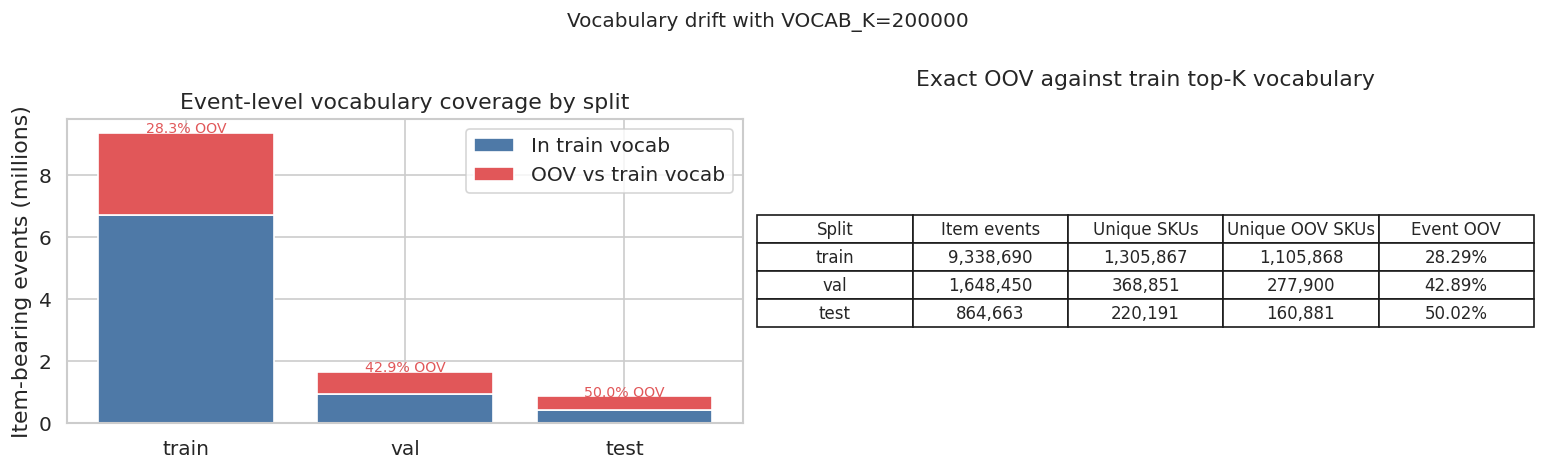

In [25]:
train_items = item_train['sku'].astype(int)
train_vocab = set(train_items.value_counts().head(VOCAB_K - 1).index)


def split_item_series(df: pl.DataFrame) -> pd.Series:
    return (
        df.filter(pl.col('sku').is_not_null())
          .select(pl.col('sku').cast(pl.Int64, strict=False).alias('sku'))
          .to_pandas()['sku']
          .astype(int)
    )

val_items = split_item_series(ev_val)
test_items = split_item_series(ev_test)

stats = []
for split_name, ser in [('train', train_items), ('val', val_items), ('test', test_items)]:
    total_events = len(ser)
    unique_skus = ser.nunique()
    if split_name == 'train':
        oov_events = total_events - int(ser.isin(train_vocab).sum())
        new_unique = unique_skus - len(set(ser.unique()) & train_vocab)
    else:
        oov_mask = ~ser.isin(train_vocab)
        oov_events = int(oov_mask.sum())
        new_unique = len(set(ser.unique()) - train_vocab)
    stats.append({
        'split': split_name,
        'item_events': total_events,
        'unique_skus': unique_skus,
        'new_unique_skus': new_unique,
        'event_oov_rate': oov_events / total_events * 100,
    })

drift_df = pd.DataFrame(stats)
print(drift_df.to_string(index=False, formatters={'event_oov_rate': lambda v: f'{v:.2f}%'}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

known_ev = [r['item_events'] * (1 - r['event_oov_rate'] / 100) for r in stats]
oov_ev = [r['item_events'] * (r['event_oov_rate'] / 100) for r in stats]
x = np.arange(len(stats))
axes[0].bar(x, np.array(known_ev) / 1e6, label='In train vocab', color='#4e79a7', edgecolor='white')
axes[0].bar(x, np.array(oov_ev) / 1e6, bottom=np.array(known_ev) / 1e6,
            label='OOV vs train vocab', color='#e15759', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels([r['split'] for r in stats])
axes[0].set_ylabel('Item-bearing events (millions)')
axes[0].set_title('Event-level vocabulary coverage by split')
axes[0].legend()
for i, r in enumerate(stats):
    axes[0].text(i, (r['item_events'] / 1e6) + 0.01, f"{r['event_oov_rate']:.1f}% OOV", ha='center', fontsize=8.5, color='#e15759')

axes[1].axis('off')
table_rows = [[
    r['split'],
    f"{r['item_events']:,}",
    f"{r['unique_skus']:,}",
    f"{r['new_unique_skus']:,}",
    f"{r['event_oov_rate']:.2f}%",
] for r in stats]
tbl = axes[1].table(
    cellText=table_rows,
    colLabels=['Split', 'Item events', 'Unique SKUs', 'Unique OOV SKUs', 'Event OOV'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.15, 1.7)
axes[1].set_title('Exact OOV against train top-K vocabulary', pad=20)

plt.suptitle(f'Vocabulary drift with VOCAB_K={VOCAB_K}', fontsize=12)
plt.tight_layout()
plt.show()

## 12 · Data quality pass
Checks that the notebook summary is aligned with the current preprocessing pipeline rather than the earlier sampled-page-visit EDA snapshot.

In [26]:
print('=' * 65)
print('DATA QUALITY REPORT')
print('=' * 65)

print('\n1. Raw vs deduped item-bearing counts:')
for name in ITEM_EVENTS:
    print(f'  {name:25}: raw={raw_counts[name]:>10,}  cleaned={len(item_dfs[name]):>10,}  removed={raw_counts[name] - len(item_dfs[name]):>8,}')

print('\n2. Timestamp sanity after cleanup:')
for name in ITEM_EVENTS:
    df = item_dfs[name]
    out_of_range = ((df.timestamp < DS_START_TS) | (df.timestamp > DS_END_TS)).sum()
    status = 'OK' if out_of_range == 0 else f'WARN: {out_of_range} out-of-range rows remain'
    print(f'  {name:25}: {status}')

print('\n3. Page-visit-only sessions after preprocess.py:')
pv_only_sessions = (
    events_30.group_by('session_id')
             .agg(pl.col('event_type').unique().alias('types'))
             .filter((pl.col('types').list.len() == 1) & (pl.col('types').list.get(0) == 'page_visit'))
             .height
)
print(f'  remaining page_visit-only sessions: {pv_only_sessions:,}')

print('\n4. Simultaneous events (same client+timestamp) in post-preprocessing corpus:')
simult = events_30.group_by(['client_id', 'timestamp']).len().get_column('len').to_numpy()
n_simult = int((simult > 1).sum())
print(f'  (client, ts) pairs with >1 event: {n_simult:,} ({n_simult/len(simult)*100:.2f}% of all timestamp pairs)')

print('\n5. Orphaned remove_from_cart within the training split:')
train_item_pd = (
    ev_train.filter(pl.col('event_type').is_in(['add_to_cart', 'remove_from_cart']))
            .drop_nulls('sku')
            .select(['client_id', 'timestamp', 'session_id', 'sku', 'event_type'])
            .with_columns(pl.col('sku').cast(pl.Int64, strict=False))
            .to_pandas()
)
atc_ev = train_item_pd[train_item_pd.event_type == 'add_to_cart'].rename(columns={'timestamp': 'atc_ts'})
rfc_ev = train_item_pd[train_item_pd.event_type == 'remove_from_cart'].rename(columns={'timestamp': 'rfc_ts'})
rfc_check = rfc_ev.merge(atc_ev[['session_id', 'sku', 'atc_ts']], on=['session_id', 'sku'], how='left')
rfc_check = rfc_check[rfc_check.atc_ts < rfc_check.rfc_ts]
n_rfc_prior = rfc_check[['client_id', 'rfc_ts', 'sku']].drop_duplicates().__len__()
n_rfc_total = len(rfc_ev)
n_orphan_rfc = n_rfc_total - n_rfc_prior
print(f'  remove_from_cart with no prior ATC same session/SKU: {n_orphan_rfc:,} ({n_orphan_rfc/n_rfc_total*100:.1f}%)')

DATA QUALITY REPORT

1. Raw vs deduped item-bearing counts:
  add_to_cart              : raw= 7,541,117  cleaned= 7,379,444  removed= 161,673
  remove_from_cart         : raw= 2,688,894  cleaned= 2,535,219  removed= 153,675
  product_buy              : raw= 2,318,502  cleaned= 1,937,579  removed= 380,923

2. Timestamp sanity after cleanup:
  add_to_cart              : OK
  remove_from_cart         : OK
  product_buy              : OK

3. Page-visit-only sessions after preprocess.py:


  remaining page_visit-only sessions: 0

4. Simultaneous events (same client+timestamp) in post-preprocessing corpus:


  (client, ts) pairs with >1 event: 18,719,734 (23.03% of all timestamp pairs)

5. Orphaned remove_from_cart within the training split:


  remove_from_cart with no prior ATC same session/SKU: 886,655 (45.9%)


Session-end action distribution (training):
  page_visit          : 3,888,359  (71.5% of sessions)
  search_query        :  445,849  (8.2% of sessions)
  add_to_cart         :  425,747  (7.8% of sessions)
  remove_from_cart    :  148,819  (2.7% of sessions)
  product_buy         :  531,376  (9.8% of sessions)



Single-event sessions: 399,398 (7.3% of all sessions)
Single-event session action distribution:
  page_visit          :        0  (0.0%)
  search_query        :   55,212  (13.8%)
  add_to_cart         :   43,938  (11.0%)
  remove_from_cart    :   13,322  (3.3%)
  product_buy         :  286,926  (71.8%)

P(event is terminal | action type):
  page_visit          : 5.65%  (3,888,359 / 68,846,102)
  search_query        : 4.47%  (445,849 / 9,984,908)
  add_to_cart         : 7.29%  (425,747 / 5,843,051)
  remove_from_cart    : 7.70%  (148,819 / 1,933,424)
  product_buy         : 34.00%  (531,376 / 1,562,654)


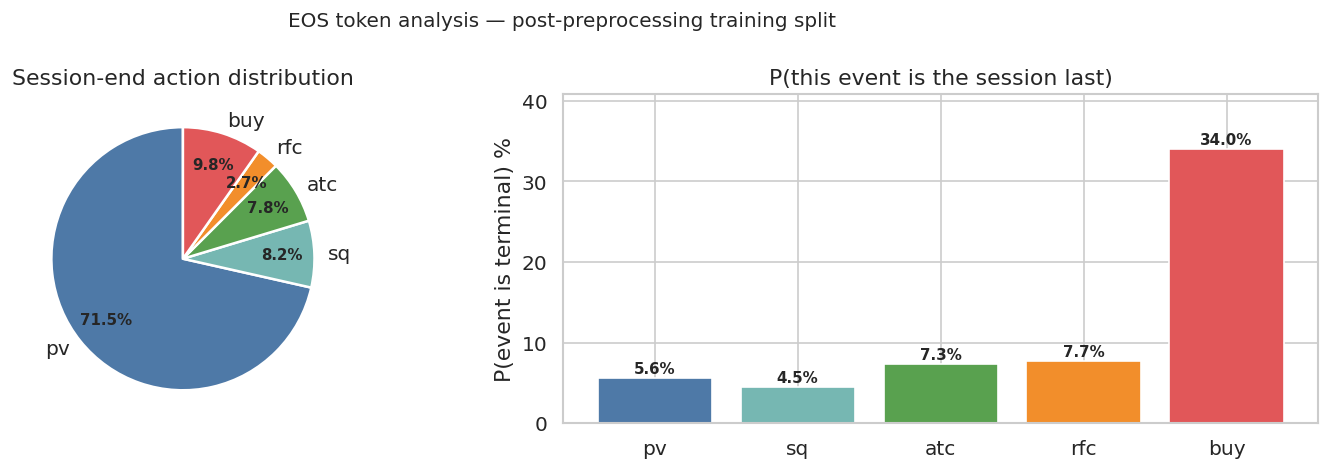


P(terminal) ranked:
  buy (product_buy         ): 34.0%
  rfc (remove_from_cart    ): 7.7%
  atc (add_to_cart         ): 7.3%
  pv  (page_visit          ): 5.6%
  sq  (search_query        ): 4.5%

Interpretation: after removing page-visit-only sessions, EOS is no longer dominated by trivial browse-only sessions; terminal-action patterns should be read from the filtered training corpus actually seen by the model.


In [27]:
# EOS / terminal-action analysis on the post-preprocessing training split
sess_lengths = ev_train.group_by('session_id').agg(pl.len().alias('n'))
last_events = (
    ev_train.sort(['session_id', 'timestamp'])
            .group_by('session_id')
            .agg(pl.col('event_type').last().alias('last_event'))
)

last_by_type = {et: 0 for et in ACTION_TYPES}
for et, n in last_events.group_by('last_event').len().iter_rows():
    last_by_type[et] = n
all_by_type = {et: 0 for et in ACTION_TYPES}
for et, n in ev_train.group_by('event_type').len().iter_rows():
    all_by_type[et] = n

print('Session-end action distribution (training):')
for et in ACTION_TYPES:
    n = last_by_type.get(et, 0)
    print(f'  {et:20}: {n:>8,}  ({n/len(last_events)*100:.1f}% of sessions)')

single_ids = set(sess_lengths.filter(pl.col('n') == 1).get_column('session_id').to_list())
single_events = ev_train.filter(pl.col('session_id').is_in(single_ids))
single_by_type = {et: 0 for et in ACTION_TYPES}
for et, n in single_events.group_by('event_type').len().iter_rows():
    single_by_type[et] = n
n_single = len(single_ids)
print(f'\nSingle-event sessions: {n_single:,} ({n_single/len(last_events)*100:.1f}% of all sessions)')
print('Single-event session action distribution:')
for et in ACTION_TYPES:
    n = single_by_type.get(et, 0)
    share = (n / n_single * 100) if n_single else 0.0
    print(f'  {et:20}: {n:>8,}  ({share:.1f}%)')

print('\nP(event is terminal | action type):')
p_terminal = {}
for et in ACTION_TYPES:
    n_terminal = last_by_type.get(et, 0)
    n_total = all_by_type.get(et, 0)
    p = n_terminal / n_total * 100 if n_total > 0 else 0
    p_terminal[et] = p
    print(f'  {et:20}: {p:.2f}%  ({n_terminal:,} / {n_total:,})')

short_names = {'page_visit': 'pv', 'search_query': 'sq', 'add_to_cart': 'atc', 'remove_from_cart': 'rfc', 'product_buy': 'buy'}
labels_s = [short_names[et] for et in ACTION_TYPES]
end_vals = [last_by_type.get(et, 0) for et in ACTION_TYPES]
p_term_vals = [p_terminal[et] for et in ACTION_TYPES]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors_pie = ['#4e79a7', '#76b7b2', '#59a14f', '#f28e2b', '#e15759']
wedges, texts, autotexts = axes[0].pie(
    end_vals, labels=labels_s, colors=colors_pie,
    autopct=lambda p: f'{p:.1f}%' if p > 1 else '',
    startangle=90, pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for t in autotexts:
    t.set_fontsize(9)
    t.set_fontweight('bold')
axes[0].set_title('Session-end action distribution')

bars_t = axes[1].bar(labels_s, p_term_vals, color=colors_pie, edgecolor='white')
for bar, v in zip(bars_t, p_term_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_ylabel('P(event is terminal) %')
axes[1].set_title('P(this event is the session last)')
axes[1].set_ylim(0, max(p_term_vals) * 1.2 if p_term_vals else 1)

plt.suptitle('EOS token analysis — post-preprocessing training split', fontsize=12)
plt.tight_layout()
plt.show()

sorted_term = sorted(p_terminal.items(), key=lambda x: -x[1])
print('\nP(terminal) ranked:')
for et, p in sorted_term:
    print(f'  {short_names[et]:3s} ({et:20s}): {p:.1f}%')
print('\nInterpretation: after removing page-visit-only sessions, EOS is no longer dominated by trivial browse-only sessions; terminal-action patterns should be read from the filtered training corpus actually seen by the model.')

## 14 · Per-action-type SKU overlap
Checks whether shared item embedding is appropriate across ATC, RFC, and BUY.

Unique SKU counts per action type (training split):
  add_to_cart      : 1,222,608
  remove_from_cart :  677,276
  product_buy      :  539,544

Pairwise SKU set overlaps:
  |atc ∩ rfc| = 606,208  (49.6% of atc, 89.5% of rfc)
  |atc ∩ buy| = 526,688  (43.1% of atc, 97.6% of buy)
  |rfc ∩ buy| = 265,998  (39.3% of rfc, 49.3% of buy)


  |atc ∩ rfc ∩ buy| = 265,333  (21.7% of atc)



Spearman rank correlation (top-10,000 SKUs):
  atc vs rfc: ρ = 0.8553
  atc vs buy: ρ = 0.7656
  rfc vs buy: ρ = 0.6051


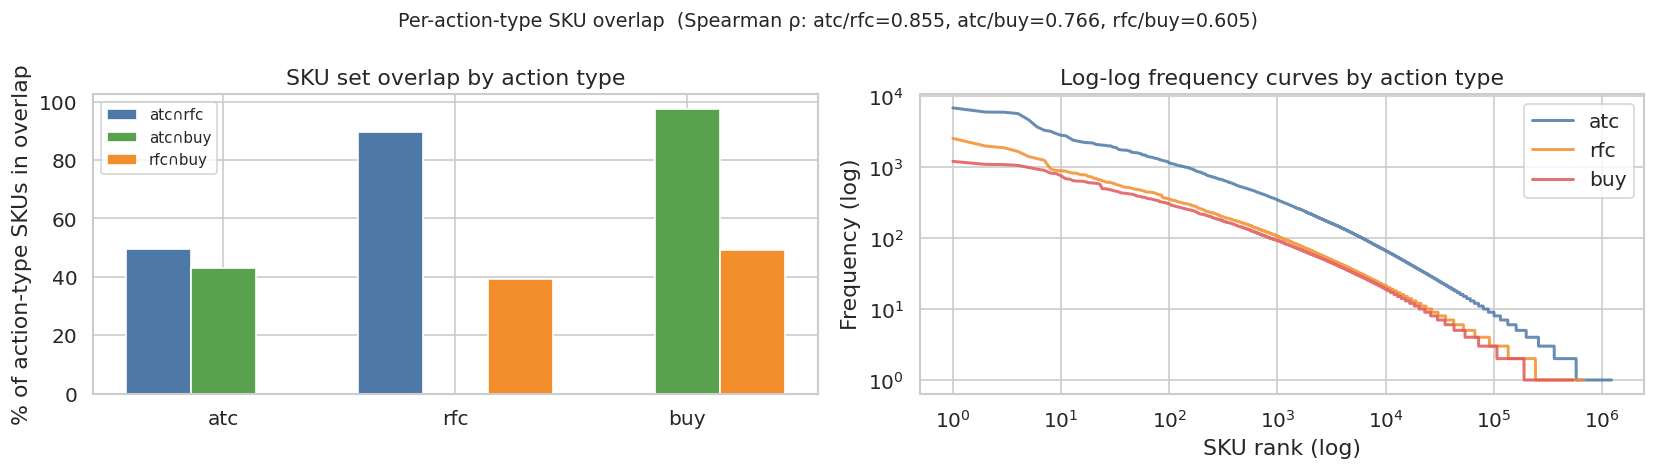


Frequency concentration (top-K SKUs covering X% of events):
  atc: top-  100 SKUs cover 3.2% of events
  atc: top-1,000 SKUs cover 11.7% of events
  atc: top-10,000 SKUs cover 31.7% of events
  rfc: top-  100 SKUs cover 3.1% of events
  rfc: top-1,000 SKUs cover 11.0% of events
  rfc: top-10,000 SKUs cover 29.7% of events
  buy: top-  100 SKUs cover 3.0% of events
  buy: top-1,000 SKUs cover 11.4% of events
  buy: top-10,000 SKUs cover 32.2% of events

Conclusion: High overlap and correlated frequency → shared item embedding is appropriate.


In [28]:
#Per-action-type SKU overlap
# scipy not available - compute Spearman rho via numpy rank correlation
def spearmanr(x, y):
    n = len(x)
    rx = pd.Series(x).rank().values
    ry = pd.Series(y).rank().values
    return np.corrcoef(rx, ry)[0, 1], None

atc_train_i = item_dfs['add_to_cart'][item_dfs['add_to_cart'].timestamp < TRAIN_CUTOFF]
rfc_train_i = item_dfs['remove_from_cart'][item_dfs['remove_from_cart'].timestamp < TRAIN_CUTOFF]
buy_train_i = item_dfs['product_buy'][item_dfs['product_buy'].timestamp < TRAIN_CUTOFF]

skus_atc = set(atc_train_i.sku.unique())
skus_rfc = set(rfc_train_i.sku.unique())
skus_buy = set(buy_train_i.sku.unique())

print('Unique SKU counts per action type (training split):')
print(f'  add_to_cart      : {len(skus_atc):>8,}')
print(f'  remove_from_cart : {len(skus_rfc):>8,}')
print(f'  product_buy      : {len(skus_buy):>8,}')

print('\nPairwise SKU set overlaps:')
def pct_overlap(a, b, name):
    inter = len(a & b)
    print(f'  |{name[0]} ∩ {name[1]}| = {inter:>7,}  ({inter/len(a)*100:.1f}% of {name[0]}, {inter/len(b)*100:.1f}% of {name[1]})')
pct_overlap(skus_atc, skus_rfc, ('atc','rfc'))
pct_overlap(skus_atc, skus_buy, ('atc','buy'))
pct_overlap(skus_rfc, skus_buy, ('rfc','buy'))
triple = skus_atc & skus_rfc & skus_buy
print(f'  |atc ∩ rfc ∩ buy| = {len(triple):>7,}  ({len(triple)/len(skus_atc)*100:.1f}% of atc)')

# Spearman rank correlation on top-10K SKUs
TOP_K = 10_000
freq_atc = atc_train_i.sku.value_counts().head(TOP_K)
freq_rfc = rfc_train_i.sku.value_counts().head(TOP_K)
freq_buy = buy_train_i.sku.value_counts().head(TOP_K)

common_ar = list(set(freq_atc.index) & set(freq_rfc.index))
common_ab = list(set(freq_atc.index) & set(freq_buy.index))
common_rb = list(set(freq_rfc.index) & set(freq_buy.index))

rho_ar, _ = spearmanr(freq_atc[common_ar].rank(ascending=False),
                       freq_rfc[common_ar].rank(ascending=False)) if len(common_ar) > 10 else (0, 1)
rho_ab, _ = spearmanr(freq_atc[common_ab].rank(ascending=False),
                       freq_buy[common_ab].rank(ascending=False)) if len(common_ab) > 10 else (0, 1)
rho_rb, _ = spearmanr(freq_rfc[common_rb].rank(ascending=False),
                       freq_buy[common_rb].rank(ascending=False)) if len(common_rb) > 10 else (0, 1)

print(f'\nSpearman rank correlation (top-{TOP_K:,} SKUs):')
print(f'  atc vs rfc: ρ = {rho_ar:.4f}')
print(f'  atc vs buy: ρ = {rho_ab:.4f}')
print(f'  rfc vs buy: ρ = {rho_rb:.4f}')

# Charts
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: SKU overlap grouped bar
action_types_3 = ['atc', 'rfc', 'buy']
sizes_3 = [len(skus_atc), len(skus_rfc), len(skus_buy)]
overlaps_vals = {
    'atc∩rfc': [len(skus_atc & skus_rfc)/len(skus_atc)*100, len(skus_atc & skus_rfc)/len(skus_rfc)*100, 0],
    'atc∩buy': [len(skus_atc & skus_buy)/len(skus_atc)*100, 0, len(skus_atc & skus_buy)/len(skus_buy)*100],
    'rfc∩buy': [0, len(skus_rfc & skus_buy)/len(skus_rfc)*100, len(skus_rfc & skus_buy)/len(skus_buy)*100],
}
x7 = np.arange(3)
w7 = 0.28
offset = [-1, 0, 1]
colors_7 = ['#4e79a7', '#59a14f', '#f28e2b']
for i, (lbl, vals7) in enumerate(overlaps_vals.items()):
    axes[0].bar(x7 + offset[i]*w7, vals7, w7, label=lbl, color=colors_7[i], edgecolor='white')
axes[0].set_xticks(x7)
axes[0].set_xticklabels(action_types_3)
axes[0].set_ylabel('% of action-type SKUs in overlap')
axes[0].set_title('SKU set overlap by action type')
axes[0].legend(fontsize=9)

# Right: log-log frequency curves
for df_f, col, lbl in [(atc_train_i,'#4e79a7','atc'),
                        (rfc_train_i,'#f28e2b','rfc'),
                        (buy_train_i,'#e15759','buy')]:
    freq = df_f.sku.value_counts().values
    axes[1].loglog(np.arange(1, len(freq)+1), freq, color=col, lw=1.8, label=lbl, alpha=0.85)
axes[1].set_xlabel('SKU rank (log)')
axes[1].set_ylabel('Frequency (log)')
axes[1].set_title('Log-log frequency curves by action type')
axes[1].legend()

plt.suptitle(f'Per-action-type SKU overlap  (Spearman ρ: atc/rfc={rho_ar:.3f}, atc/buy={rho_ab:.3f}, rfc/buy={rho_rb:.3f})',
             fontsize=11.5)
plt.tight_layout()
plt.show()

# Print frequency concentration for each action type
print('\nFrequency concentration (top-K SKUs covering X% of events):')
for df_conc, lbl in [(atc_train_i,'atc'),(rfc_train_i,'rfc'),(buy_train_i,'buy')]:
    freq_s = df_conc.sku.value_counts()
    cum_s  = freq_s.cumsum()
    total_s = len(df_conc)
    for k in [100, 1000, 10000]:
        pct = cum_s.iloc[min(k,len(freq_s))-1] / total_s * 100
        print(f'  {lbl}: top-{k:>5,} SKUs cover {pct:.1f}% of events')
print(f'\nConclusion: High overlap and correlated frequency → shared item embedding is appropriate.')


## 15 · Session type taxonomy & conversion funnel
Computed on the post-preprocessing training split, so the funnel excludes sessions that were dropped upstream (e.g. page-visit-only sessions).

Session type distribution (training):
  browse    :  110,054  (2.0%)  mean_len=8.6  median_len=6
  search    : 1,784,532  (32.8%)  mean_len=15.1  median_len=10


  cart      : 2,461,564  (45.2%)  mean_len=17.5  median_len=9
  purchase  : 1,084,000  (19.9%)  mean_len=15.8  median_len=8

Conversion funnel (% of all sessions):
  Browse    : 5,440,150  (100.0%)
  Search    : 5,330,096  (98.0%)
  Cart      : 3,545,564  (65.2%)
  Purchase  : 1,084,000  (19.9%)



Users who purchased in training: 771,274 (26.2% of all users)


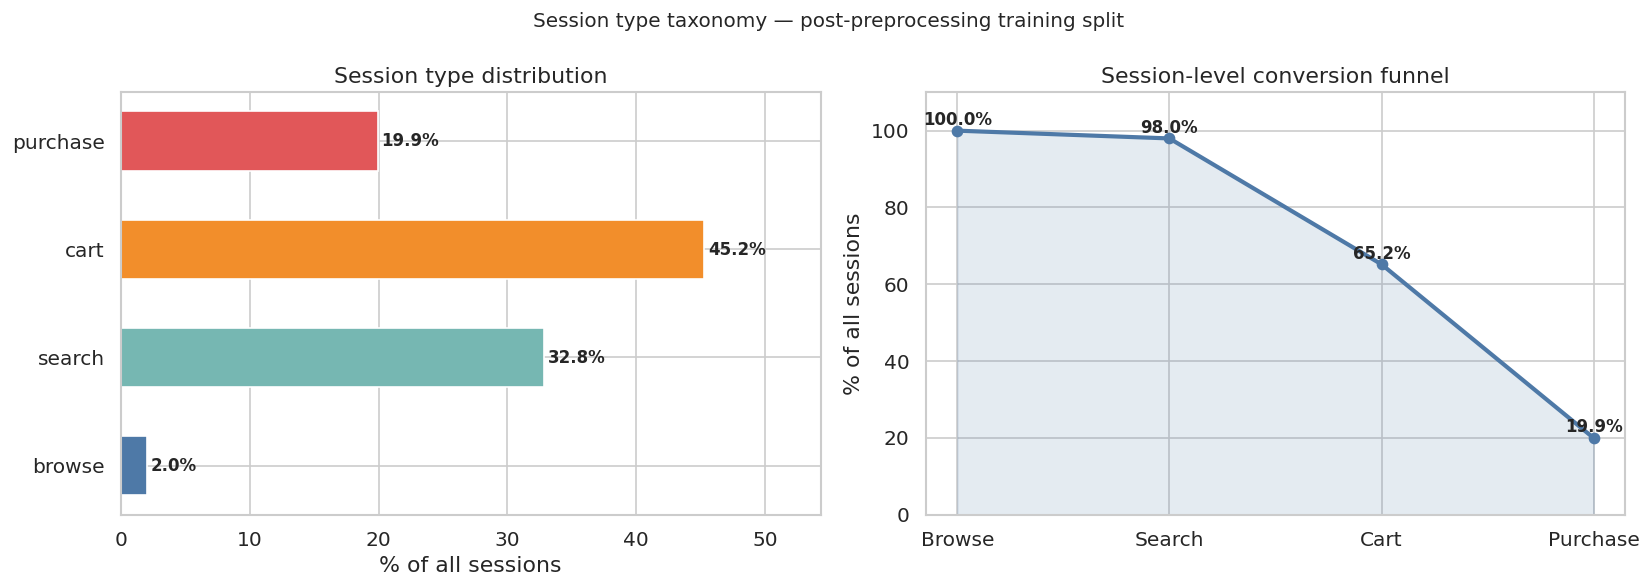

In [29]:
priority_map = {
    'product_buy': 4,
    'add_to_cart': 3,
    'search_query': 2,
    'remove_from_cart': 1,
    'page_visit': 1,
}
reverse_map = {4: 'purchase', 3: 'cart', 2: 'search', 1: 'browse'}

sess_info = (
    ev_train.select(['session_id', 'client_id', 'timestamp', 'event_type'])
            .with_columns(pl.col('event_type').replace(priority_map, default=1).cast(pl.Int32).alias('priority'))
            .group_by('session_id')
            .agg([
                pl.col('priority').max().alias('priority'),
                pl.col('client_id').first().alias('client_id'),
                pl.len().alias('session_len'),
            ])
)

sess_info_pd = sess_info.to_pandas()
sess_info_pd['sess_type'] = sess_info_pd['priority'].map(reverse_map)
total_sess = len(sess_info_pd)
type_counts = sess_info_pd['sess_type'].value_counts()

print('Session type distribution (training):')
for st in ['browse', 'search', 'cart', 'purchase']:
    n = int(type_counts.get(st, 0))
    mean_len = sess_info_pd.loc[sess_info_pd['sess_type'] == st, 'session_len'].mean()
    med_len = sess_info_pd.loc[sess_info_pd['sess_type'] == st, 'session_len'].median()
    print(f'  {st:10}: {n:>8,}  ({n/total_sess*100:.1f}%)  mean_len={mean_len:.1f}  median_len={med_len:.0f}')

n_browse = int(type_counts.get('browse', 0))
n_search = int(type_counts.get('search', 0))
n_cart = int(type_counts.get('cart', 0))
n_purchase = int(type_counts.get('purchase', 0))

print('\nConversion funnel (% of all sessions):')
for label, n in [('Browse', n_browse + n_search + n_cart + n_purchase),
                 ('Search', n_search + n_cart + n_purchase),
                 ('Cart', n_cart + n_purchase),
                 ('Purchase', n_purchase)]:
    print(f'  {label:10}: {n:>8,}  ({n/total_sess*100:.1f}%)')

buyers = sess_info_pd.loc[sess_info_pd['sess_type'] == 'purchase', 'client_id'].nunique()
all_users_train = sess_info_pd['client_id'].nunique()
frac_buyers = buyers / all_users_train * 100
print(f'\nUsers who purchased in training: {buyers:,} ({frac_buyers:.1f}% of all users)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

st_order = ['browse', 'search', 'cart', 'purchase']
st_fracs = [type_counts.get(st, 0) / total_sess * 100 for st in st_order]
st_colors = ['#4e79a7', '#76b7b2', '#f28e2b', '#e15759']
bars_st = axes[0].barh(st_order, st_fracs, color=st_colors, edgecolor='white', height=0.55)
for bar, v in zip(bars_st, st_fracs):
    axes[0].text(v + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')
axes[0].set_xlabel('% of all sessions')
axes[0].set_xlim(0, max(st_fracs) * 1.2)
axes[0].set_title('Session type distribution')

funnel_labels = ['Browse', 'Search', 'Cart', 'Purchase']
funnel_vals = [100.0,
               (n_search + n_cart + n_purchase) / total_sess * 100,
               (n_cart + n_purchase) / total_sess * 100,
               n_purchase / total_sess * 100]
axes[1].plot(funnel_labels, funnel_vals, marker='o', lw=2.5, color='#4e79a7')
axes[1].fill_between(funnel_labels, funnel_vals, alpha=0.15, color='#4e79a7')
for x, y in zip(funnel_labels, funnel_vals):
    axes[1].text(x, y + 1.5, f'{y:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylabel('% of all sessions')
axes[1].set_ylim(0, 110)
axes[1].set_title('Session-level conversion funnel')

plt.suptitle('Session type taxonomy — post-preprocessing training split', fontsize=12)
plt.tight_layout()
plt.show()